In [ ]:
!pip install dask[dataframe]
!pip install lightgbm statsmodels xgboost

INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 6.0 MB/s eta 0:00:00


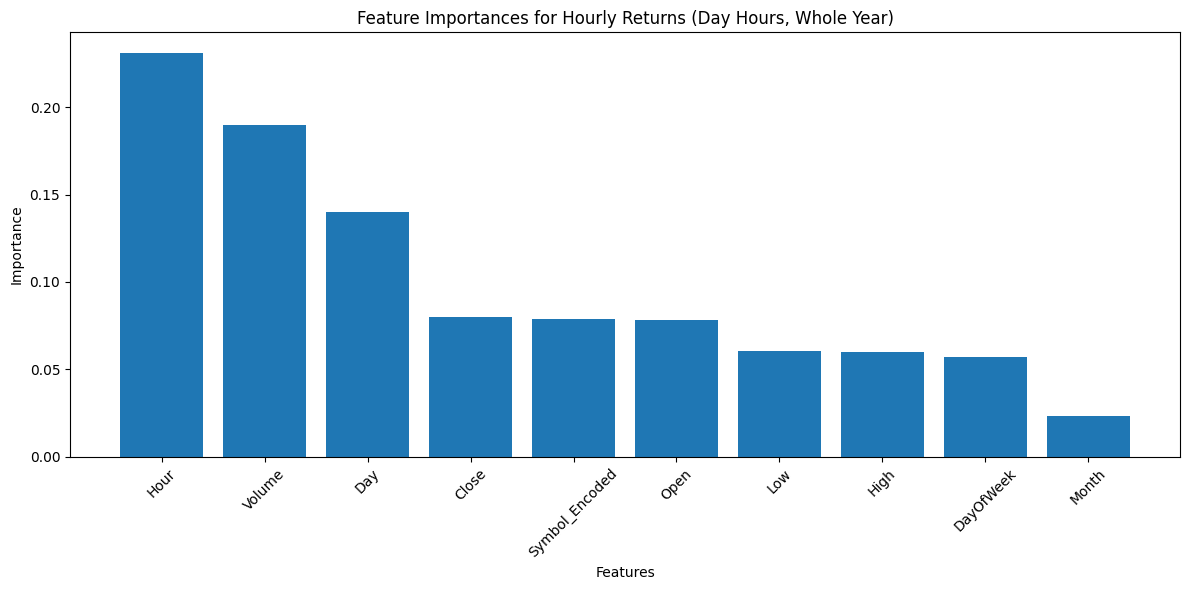

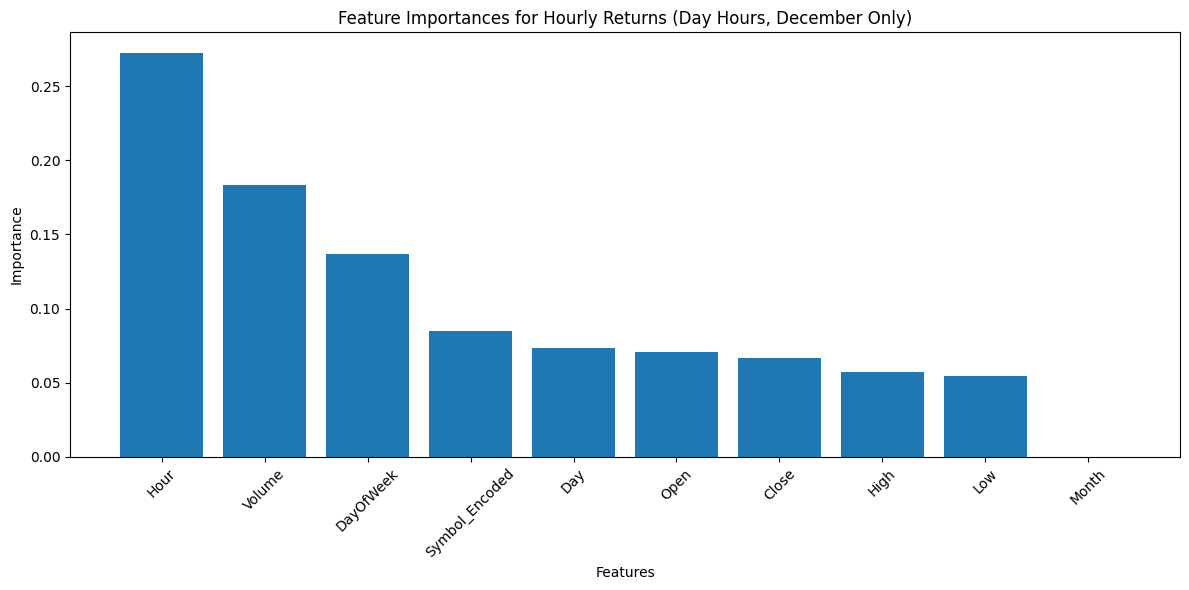

Feature Importances (Day Hours, Whole Year):
          feature  importance
5            Hour    0.231233
4          Volume    0.190040
6             Day    0.140102
3           Close    0.080045
9  Symbol_Encoded    0.079102
0            Open    0.078376
2             Low    0.060540
1            High    0.060068
8       DayOfWeek    0.057338
7           Month    0.023156

Feature Importances (Day Hours, December Only):
          feature  importance
5            Hour    0.272559
4          Volume    0.183324
8       DayOfWeek    0.136701
9  Symbol_Encoded    0.084559
6             Day    0.073408
0            Open    0.070795
3           Close    0.066852
1            High    0.056974
2             Low    0.054827
7           Month    0.000000

Top 5 Features Comparison (Day Hours):
Whole Year: Hour, Volume, Day, Close, Symbol_Encoded
December Only: Hour, Volume, DayOfWeek, Symbol_Encoded, Day


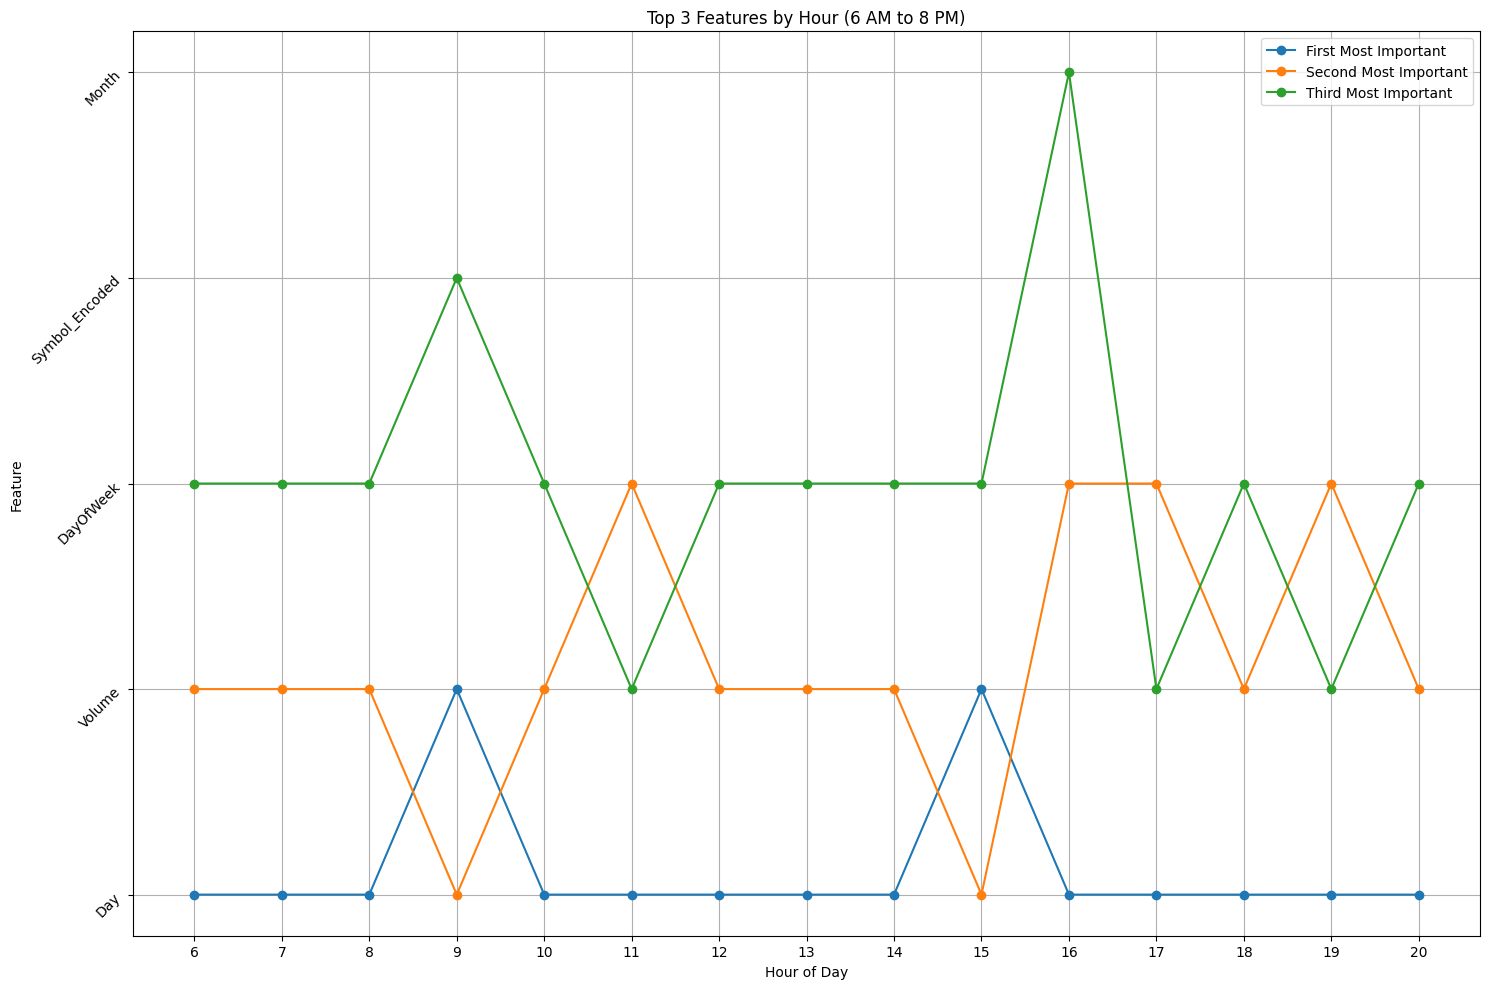

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/crypto_hourly_prices_2024.csv")

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Set Timestamp as index
df.set_index('Timestamp', inplace=True)

# Calculate hourly returns
df['Hourly_Return'] = df.groupby('Symbol')['Close'].pct_change()

# Create additional features
df['Hour'] = df.index.hour
df['Day'] = df.index.day
df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek

# Encode Symbol as numerical
le = LabelEncoder()
df['Symbol_Encoded'] = le.fit_transform(df['Symbol'])

# Filter for day hours (6 AM to 8 PM)
df_day = df[(df['Hour'] >= 6) & (df['Hour'] <= 20)]

# Function to prepare data and train model
def train_random_forest(data):
    # Prepare features and target
    features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Symbol_Encoded']
    X = data[features]
    y = data['Hourly_Return']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Random Forest model
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    # Get feature importances
    importances = rf.feature_importances_
    feature_importance = pd.DataFrame({'feature': features, 'importance': importances})
    feature_importance = feature_importance.sort_values('importance', ascending=False)

    return feature_importance

# Function to plot feature importances
def plot_feature_importances(feature_importance, title):
    plt.figure(figsize=(12, 6))
    plt.bar(feature_importance['feature'], feature_importance['importance'])
    plt.title(title)
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Analyze day hours for the whole year
day_hours_importance = train_random_forest(df_day)
plot_feature_importances(day_hours_importance, 'Feature Importances for Hourly Returns (Day Hours, Whole Year)')

# Get the latest month in the dataset
latest_month = df.index.max().month
latest_month_name = df.index.max().strftime('%B')

# Analyze day hours for the latest month only
latest_month_day_data = df_day[df_day.index.month == latest_month]
latest_month_day_importance = train_random_forest(latest_month_day_data)
plot_feature_importances(latest_month_day_importance, f'Feature Importances for Hourly Returns (Day Hours, {latest_month_name} Only)')

# Print feature importances
print("Feature Importances (Day Hours, Whole Year):")
print(day_hours_importance)
print(f"\nFeature Importances (Day Hours, {latest_month_name} Only):")
print(latest_month_day_importance)

# Compare top 5 features
print("\nTop 5 Features Comparison (Day Hours):")
print("Whole Year:", ", ".join(day_hours_importance['feature'].head().tolist()))
print(f"{latest_month_name} Only:", ", ".join(latest_month_day_importance['feature'].head().tolist()))

# Analyze hour-by-hour importance
hour_importance = {}
for hour in range(6, 21):
    hour_data = df[df['Hour'] == hour]
    hour_importance[hour] = train_random_forest(hour_data)

# Analyze top 3 features for each hour
plt.figure(figsize=(15, 10))
hours = range(6, 21)
for i, feature in enumerate(['First', 'Second', 'Third']):
    top_features = [hour_importance[hour]['feature'].iloc[i] for hour in hours]
    plt.plot(hours, top_features, marker='o', label=f'{feature} Most Important')

plt.title('Top 3 Features by Hour (6 AM to 8 PM)')
plt.xlabel('Hour of Day')
plt.ylabel('Feature')
plt.xticks(hours)
plt.yticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print top 3 features for each hour
for hour in hours:
    print(f"\nHour {hour}:00")
    print(hour_importance[hour].head(3))


Hour 6:00
     feature  importance
6        Day    0.262632
4     Volume    0.205849
8  DayOfWeek    0.156664

Hour 7:00
     feature  importance
6        Day    0.249412
4     Volume    0.225634
8  DayOfWeek    0.141863

Hour 8:00
     feature  importance
6        Day    0.246136
4     Volume    0.186469
8  DayOfWeek    0.134479

Hour 9:00
          feature  importance
4          Volume    0.246573
6             Day    0.224162
9  Symbol_Encoded    0.113166

Hour 10:00
     feature  importance
6        Day    0.213337
4     Volume    0.212923
8  DayOfWeek    0.164097

Hour 11:00
     feature  importance
6        Day    0.269722
8  DayOfWeek    0.227941
4     Volume    0.144495

Hour 12:00
     feature  importance
6        Day    0.363459
4     Volume    0.169630
8  DayOfWeek    0.123961

Hour 13:00
     feature  importance
6        Day    0.260112
4     Volume    0.203352
8  DayOfWeek    0.143437

Hour 14:00
     feature  importance
6        Day    0.295328
4     Volume    0.171521
8

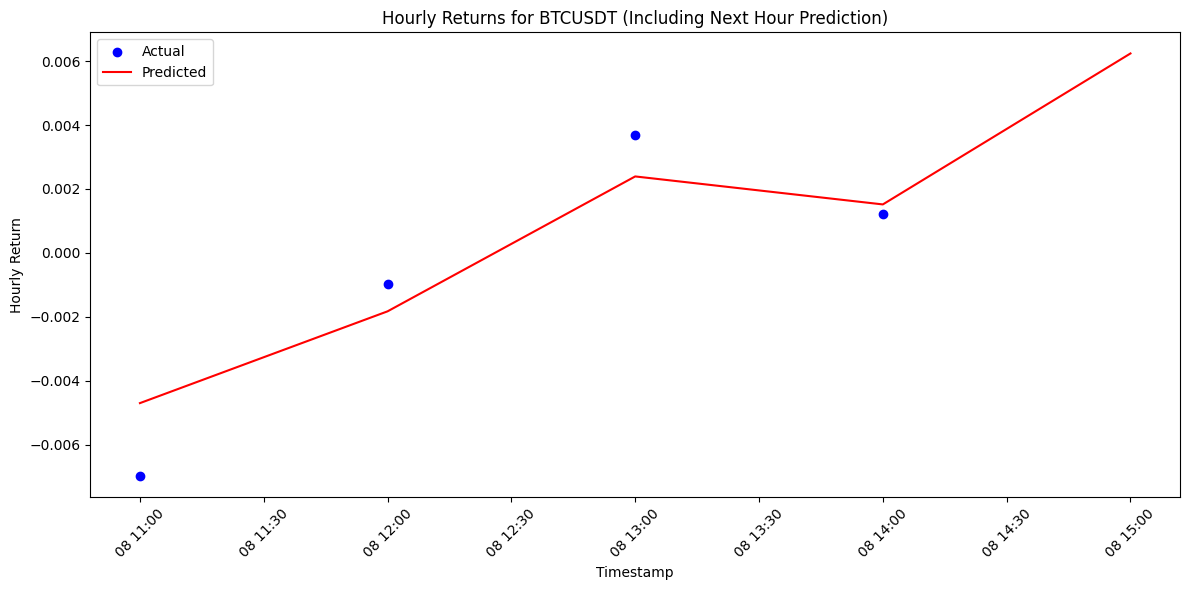

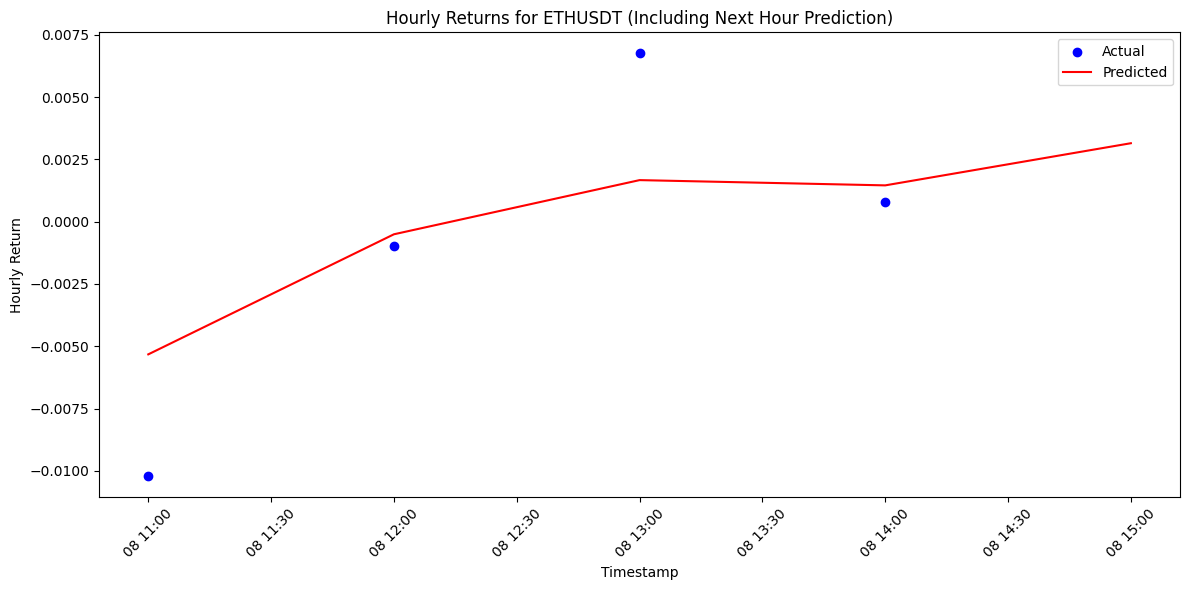

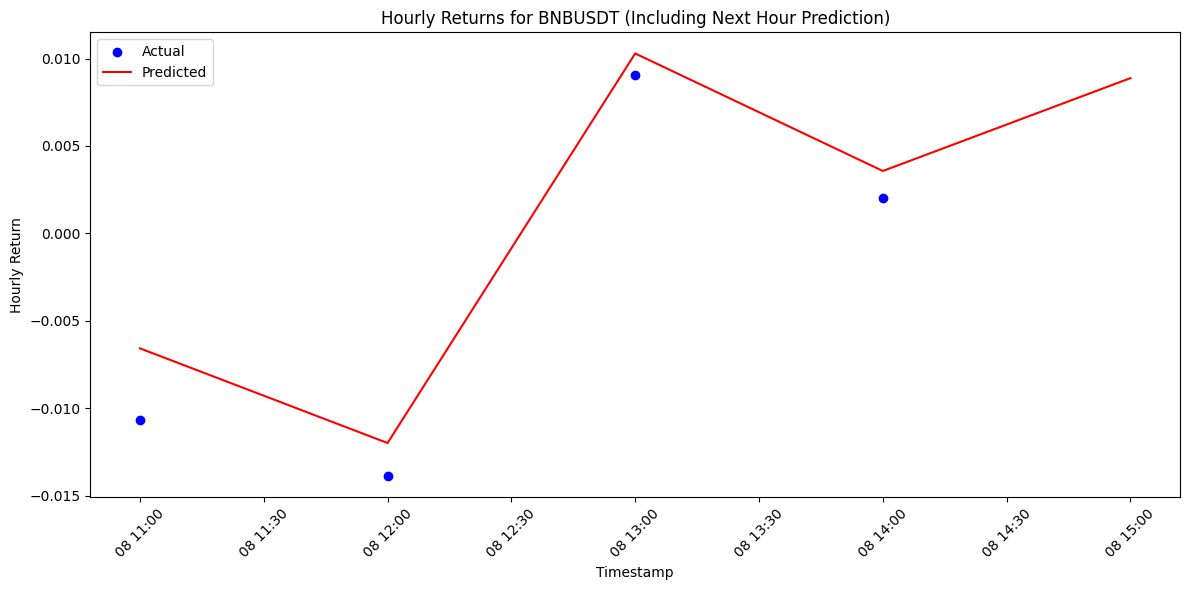

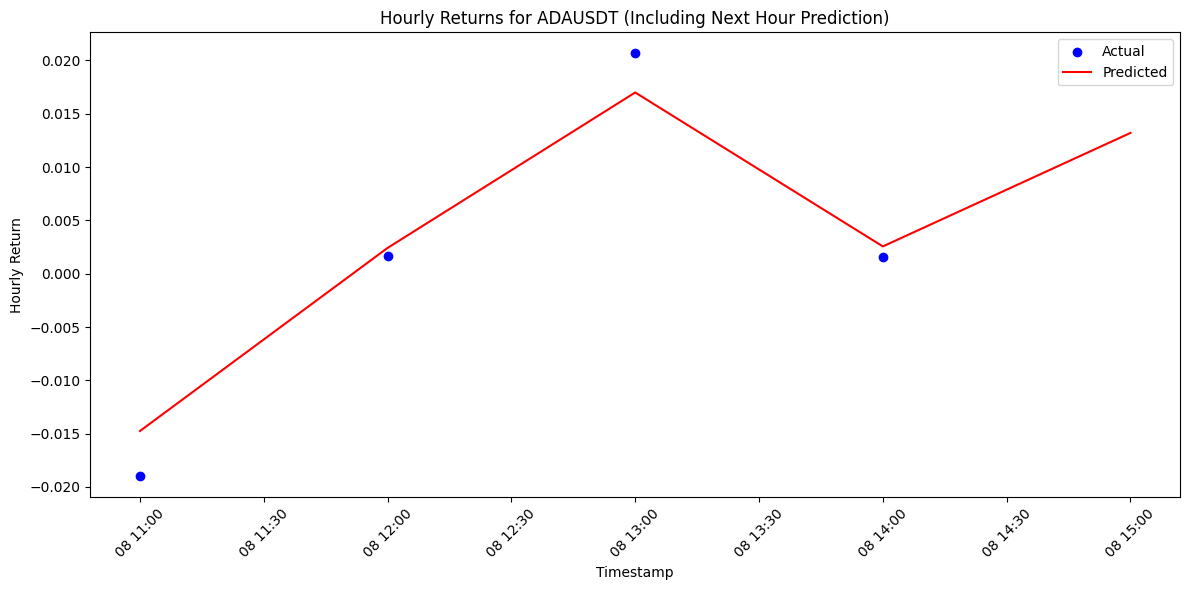

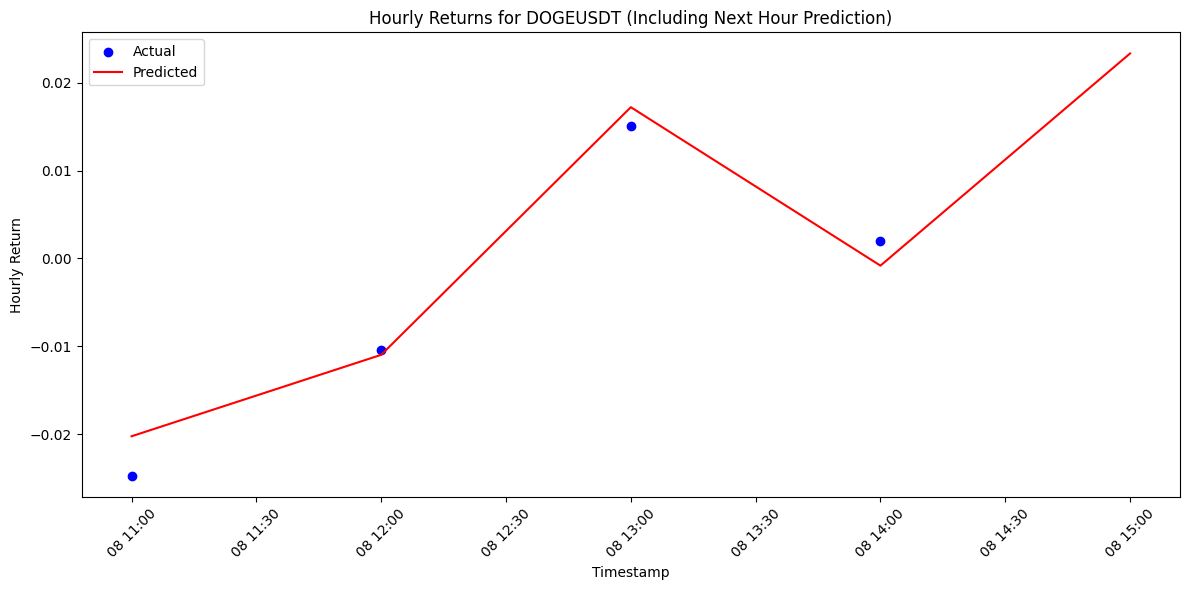

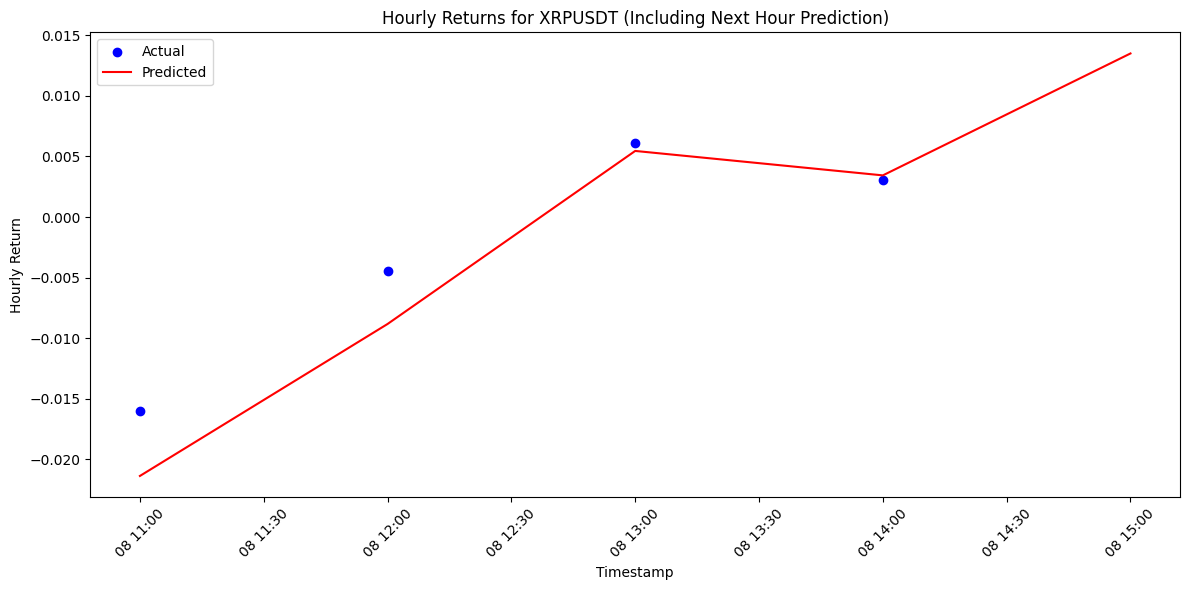

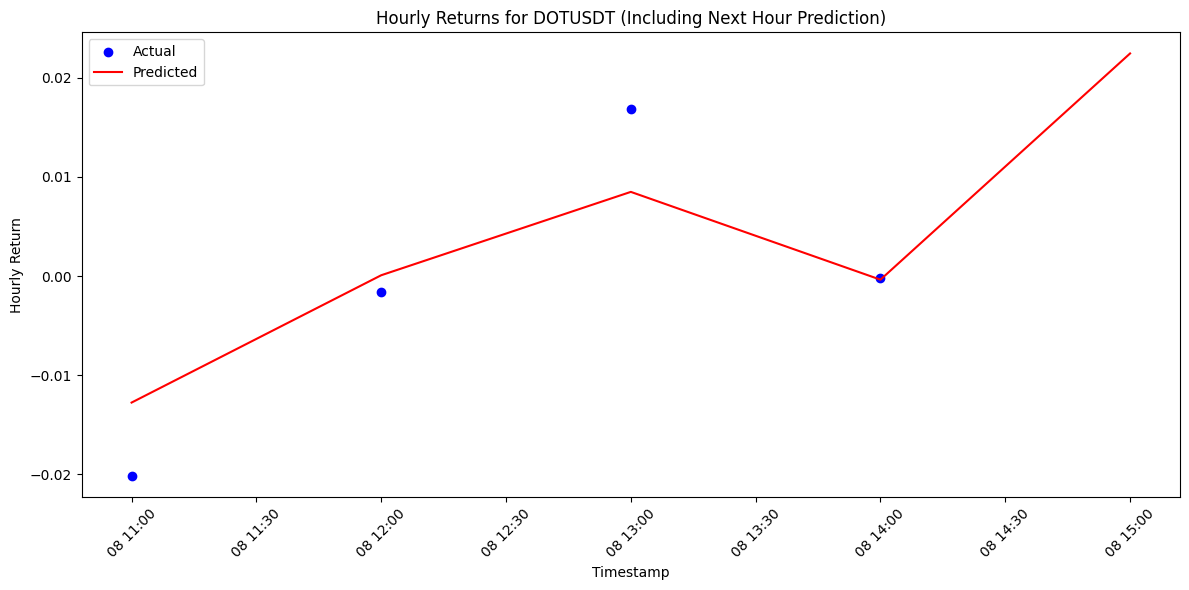

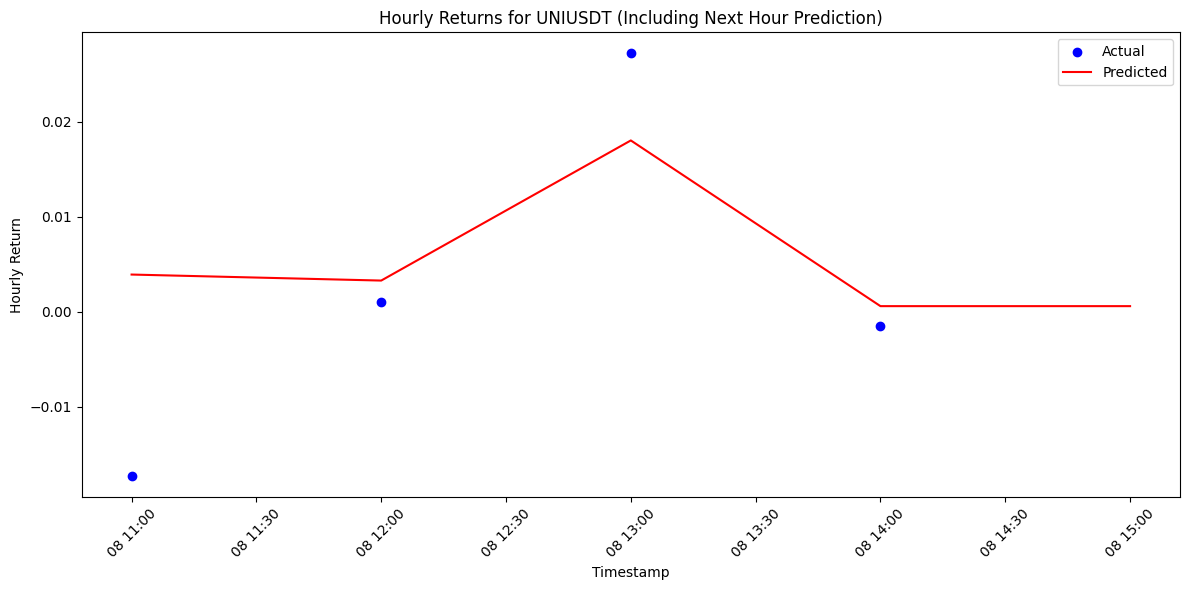

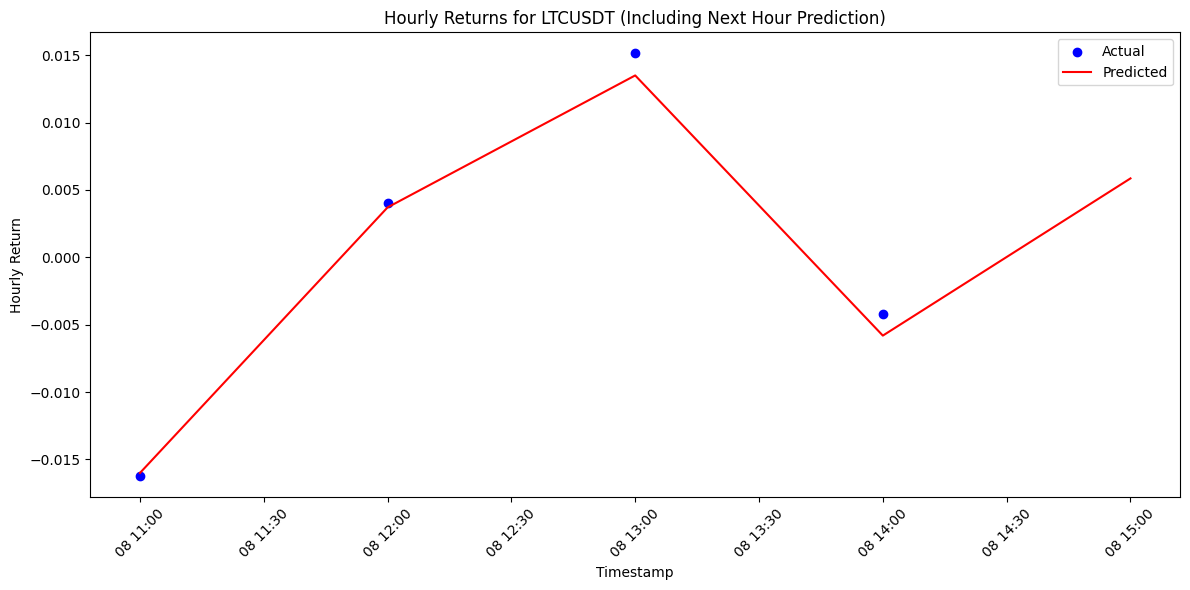

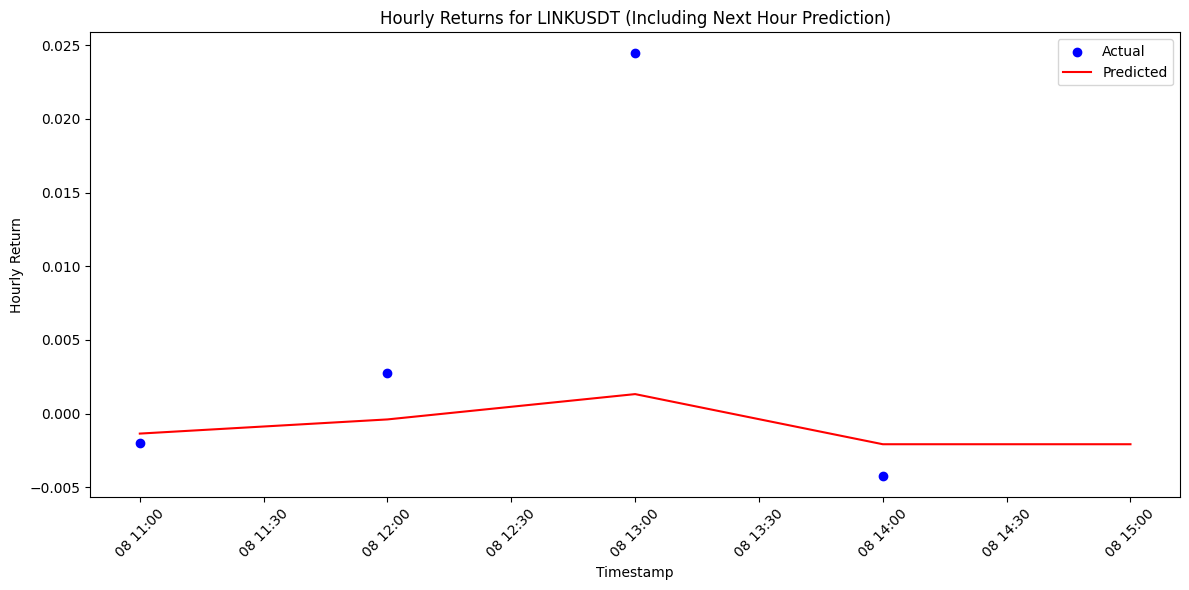

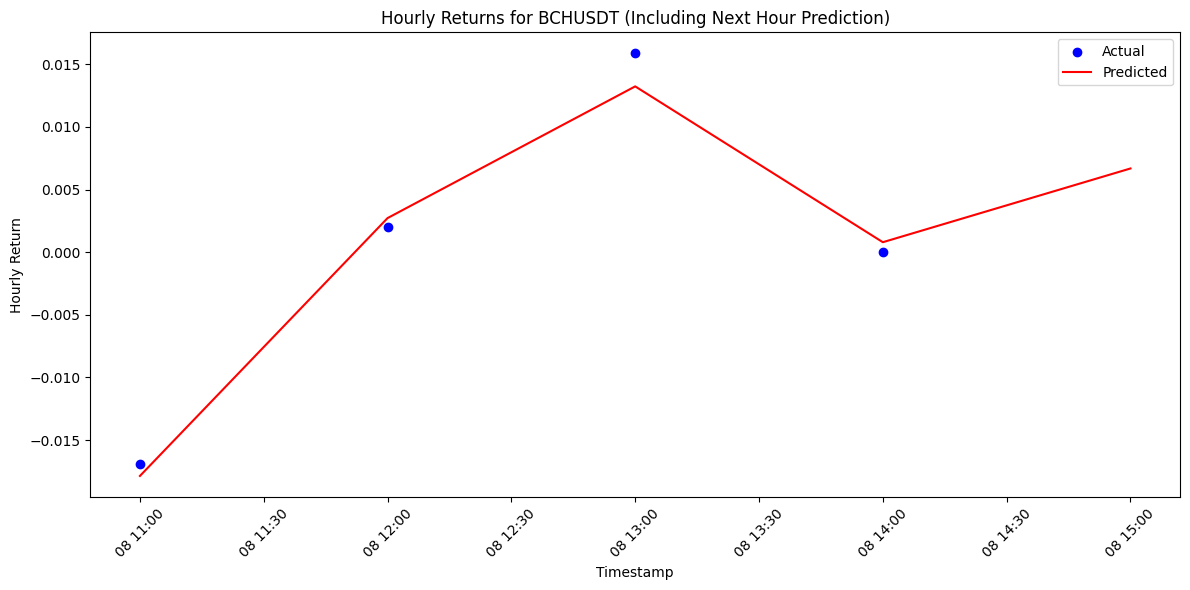

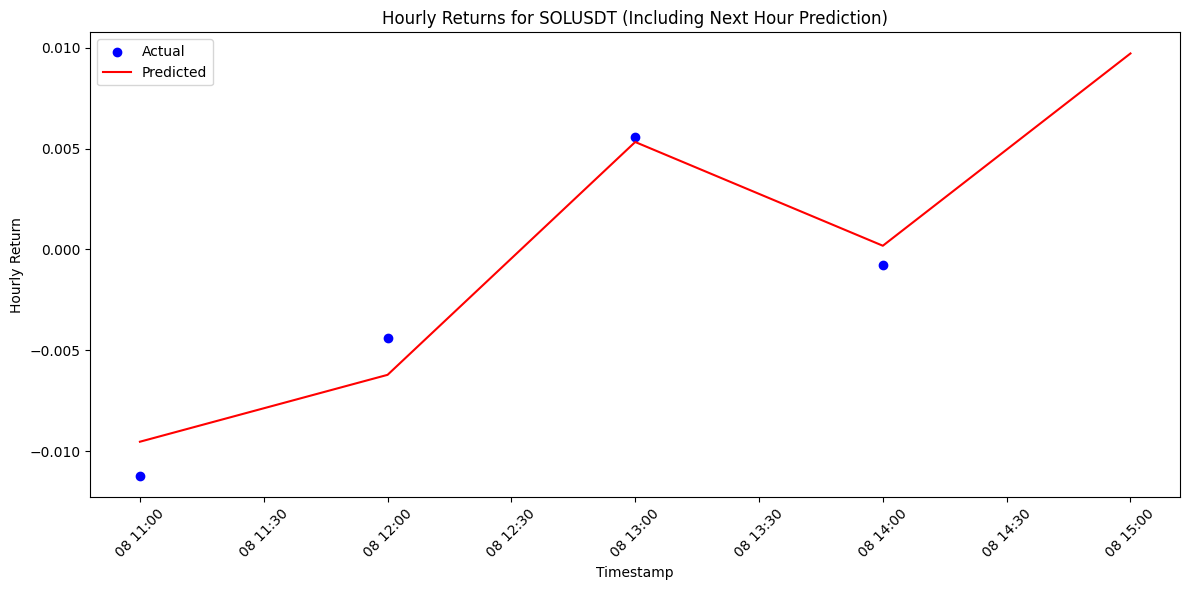

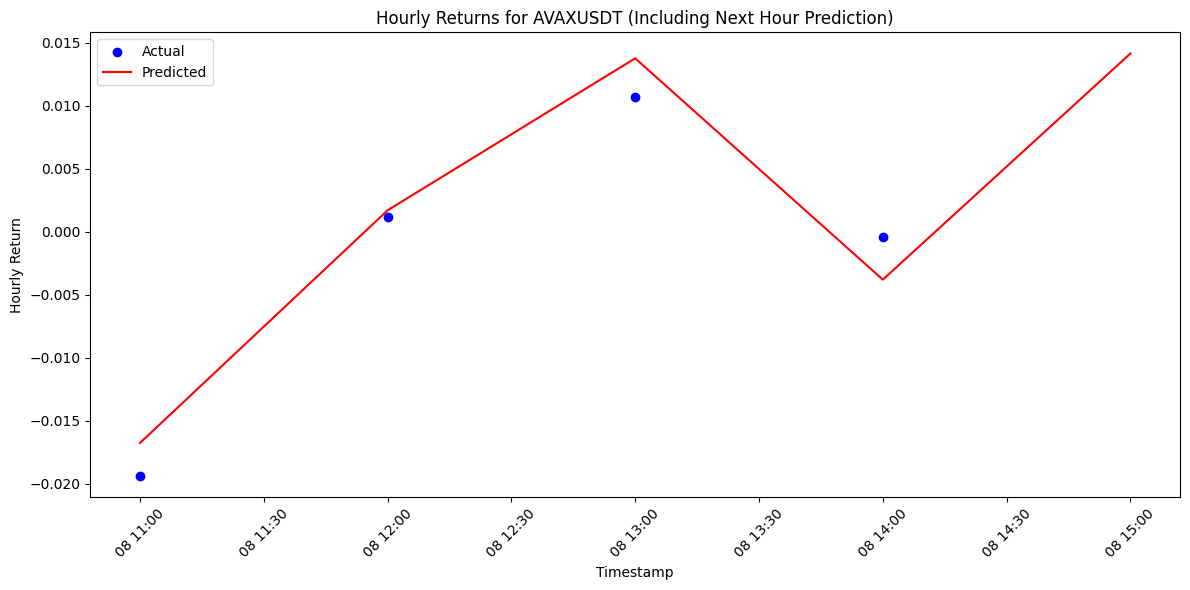

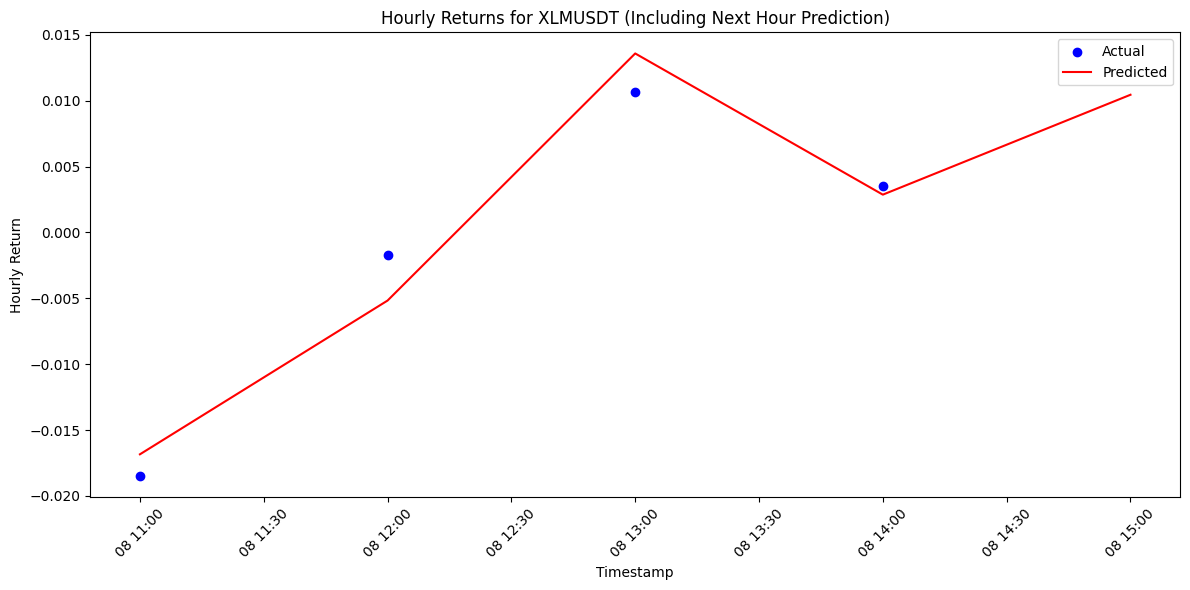

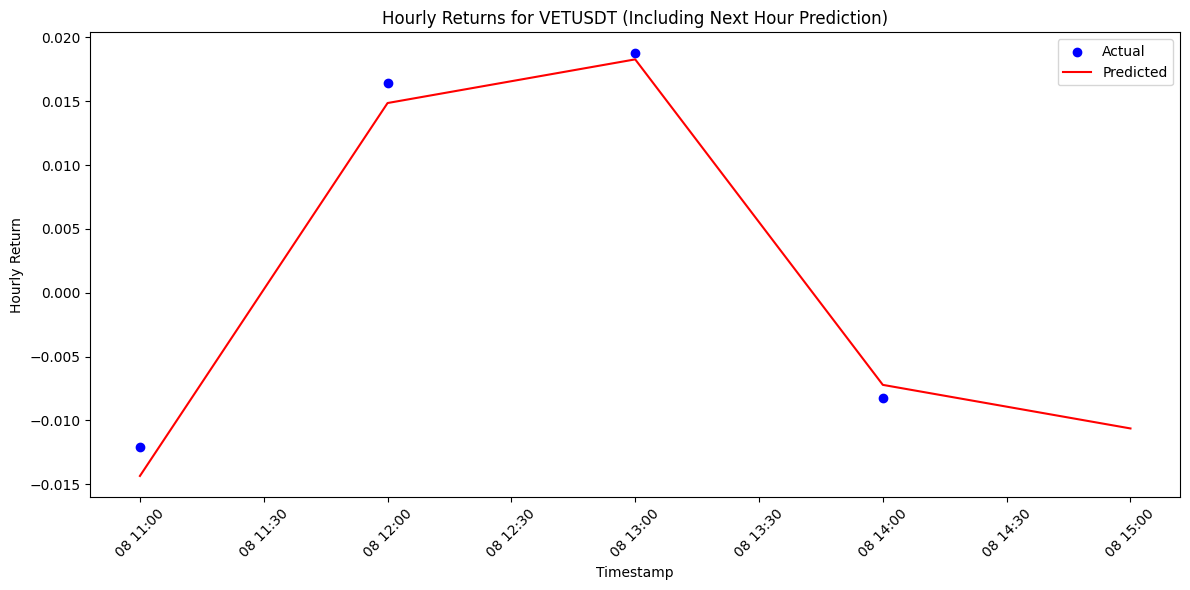

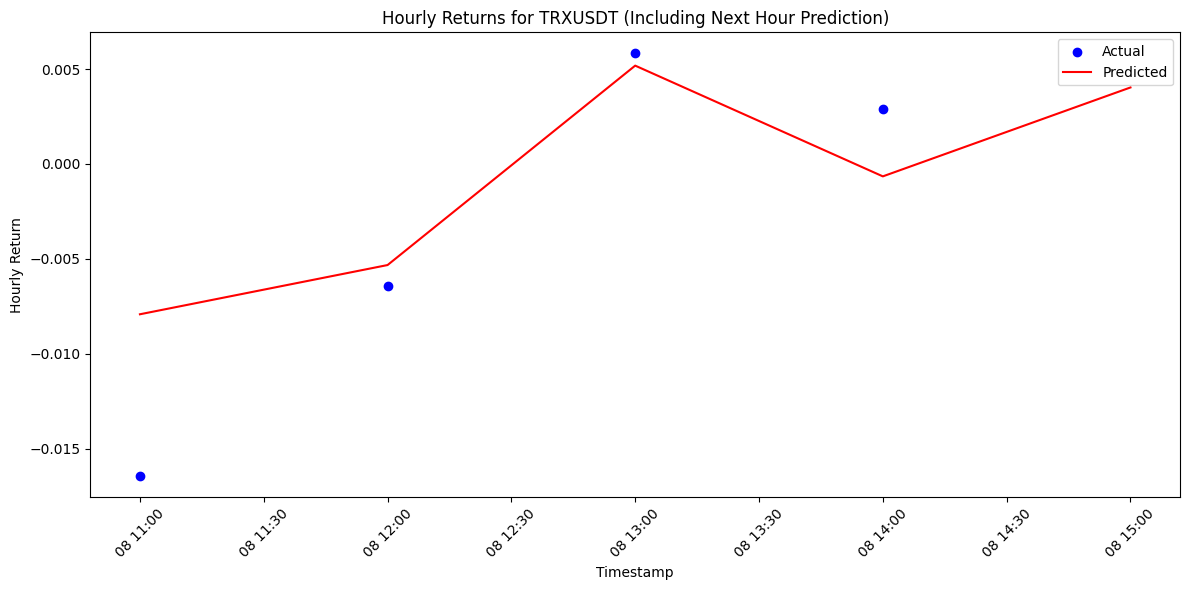

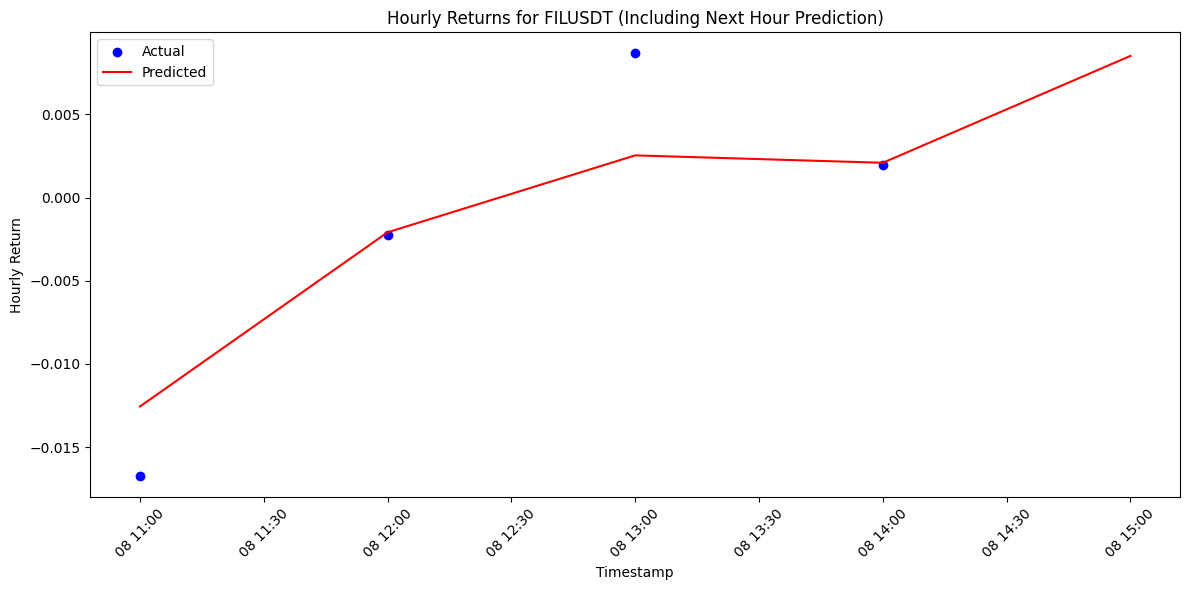

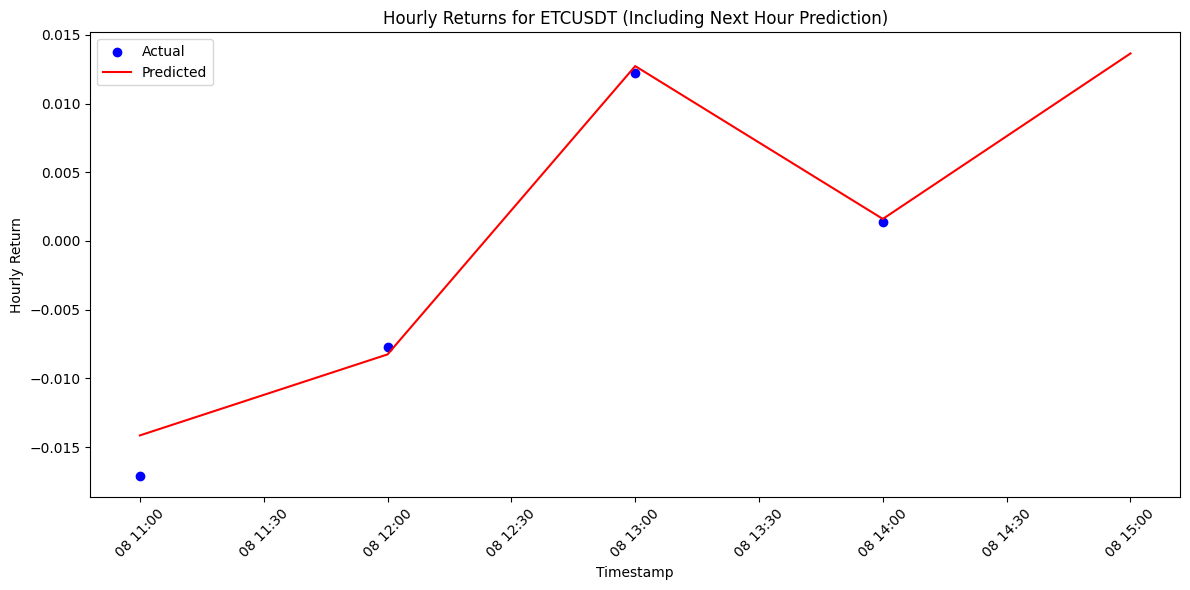

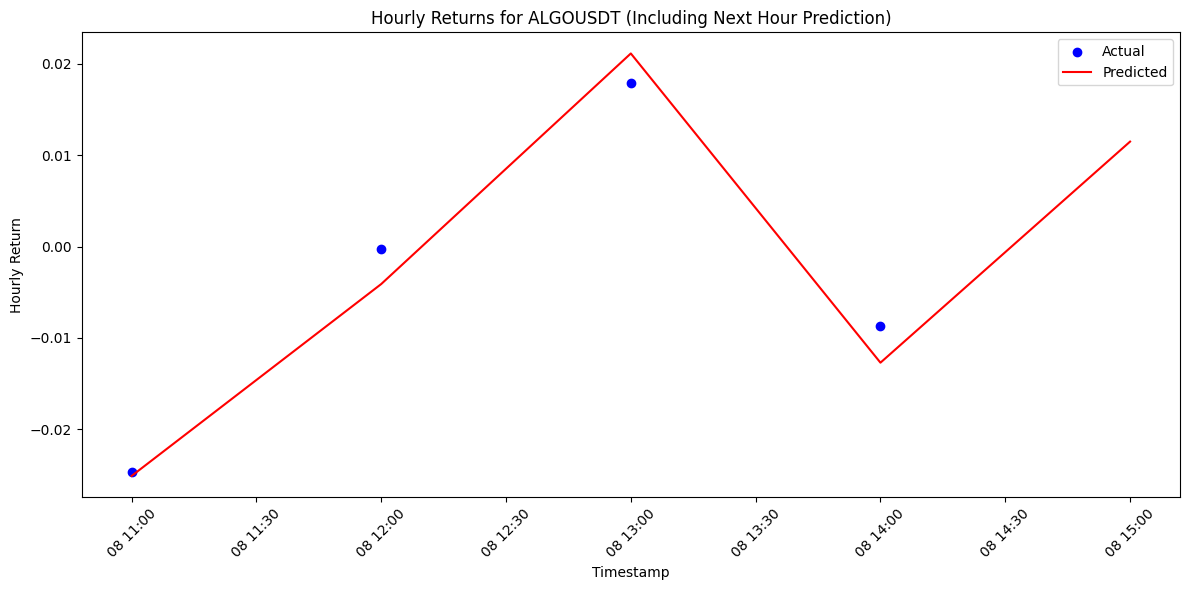

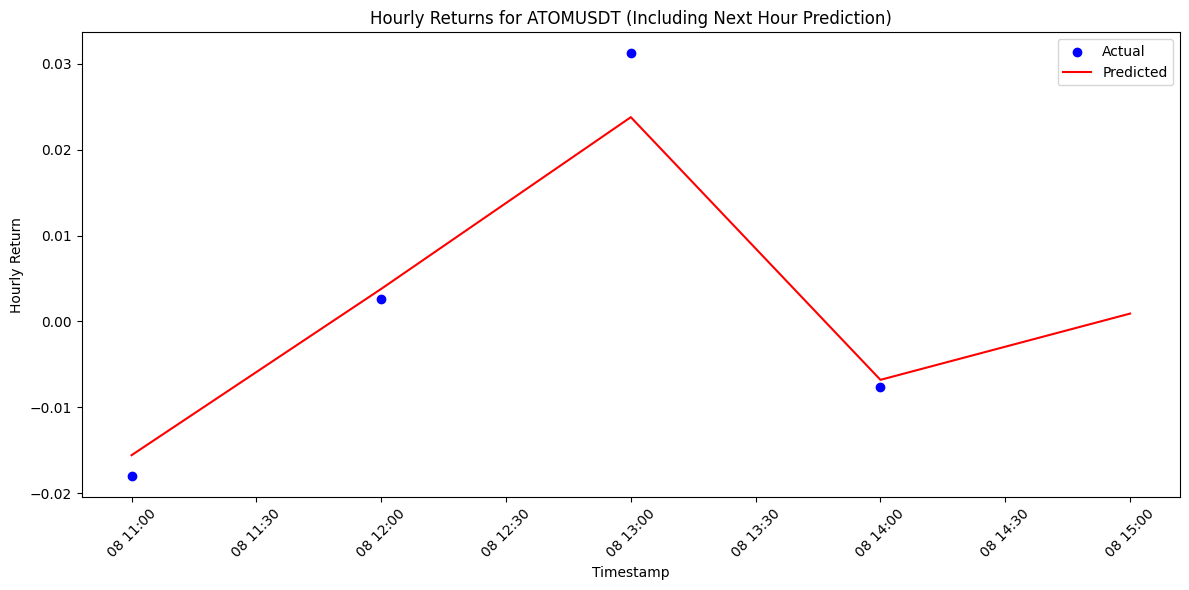

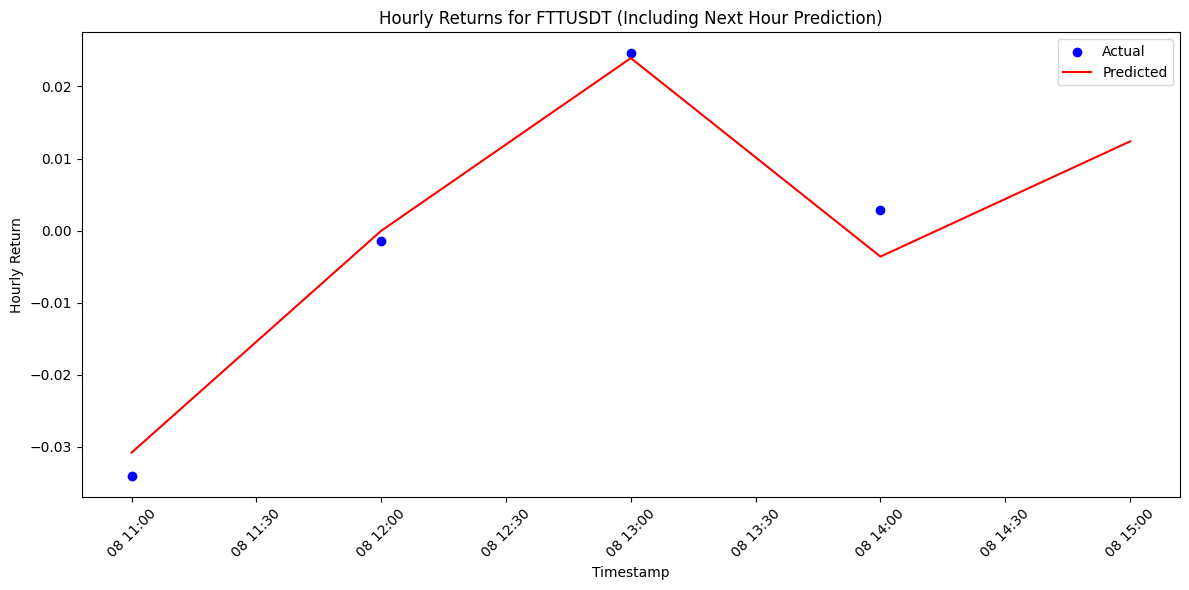

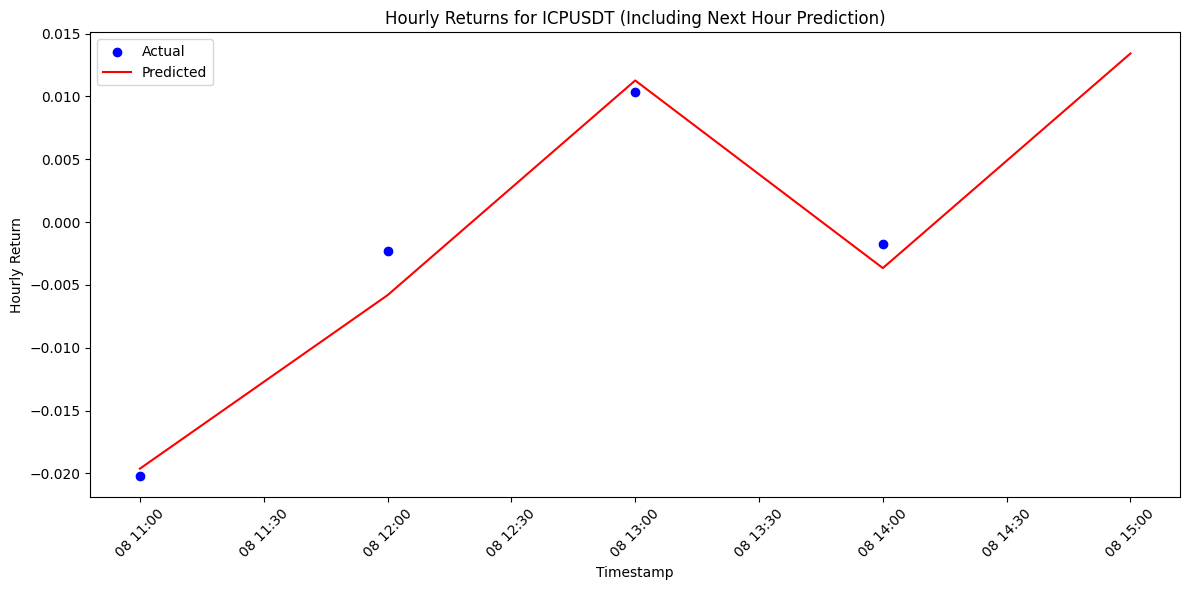

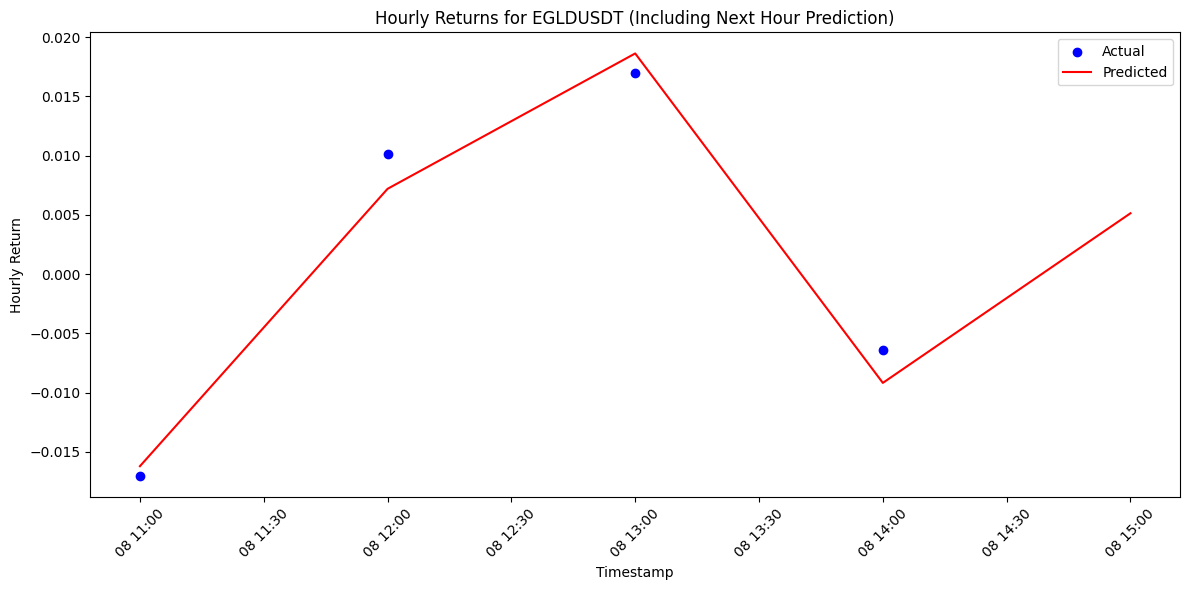

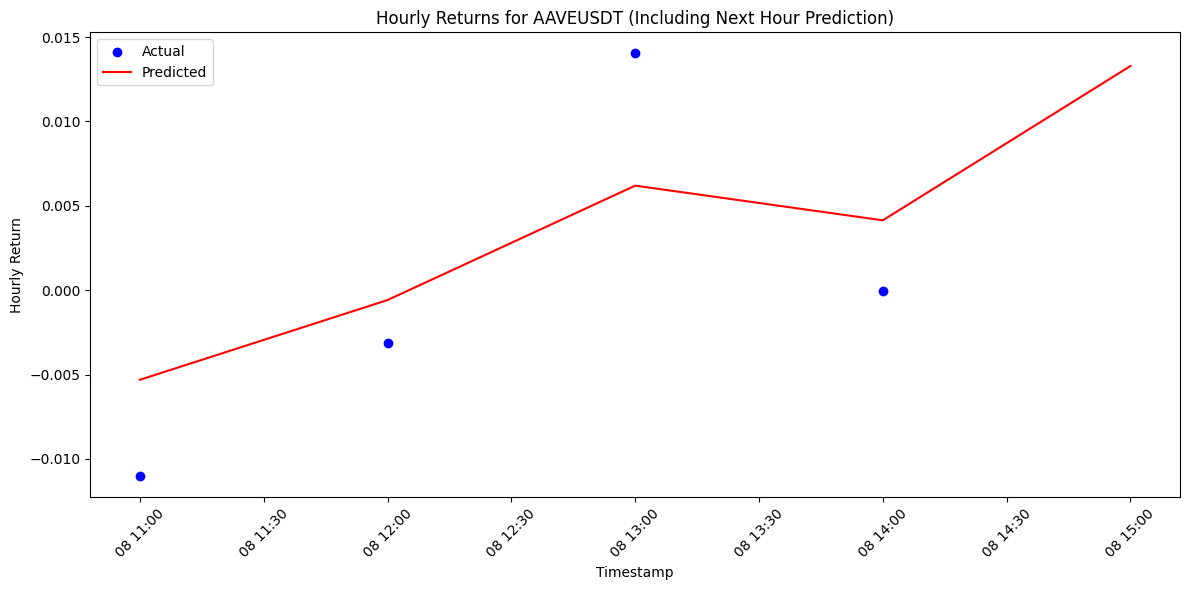

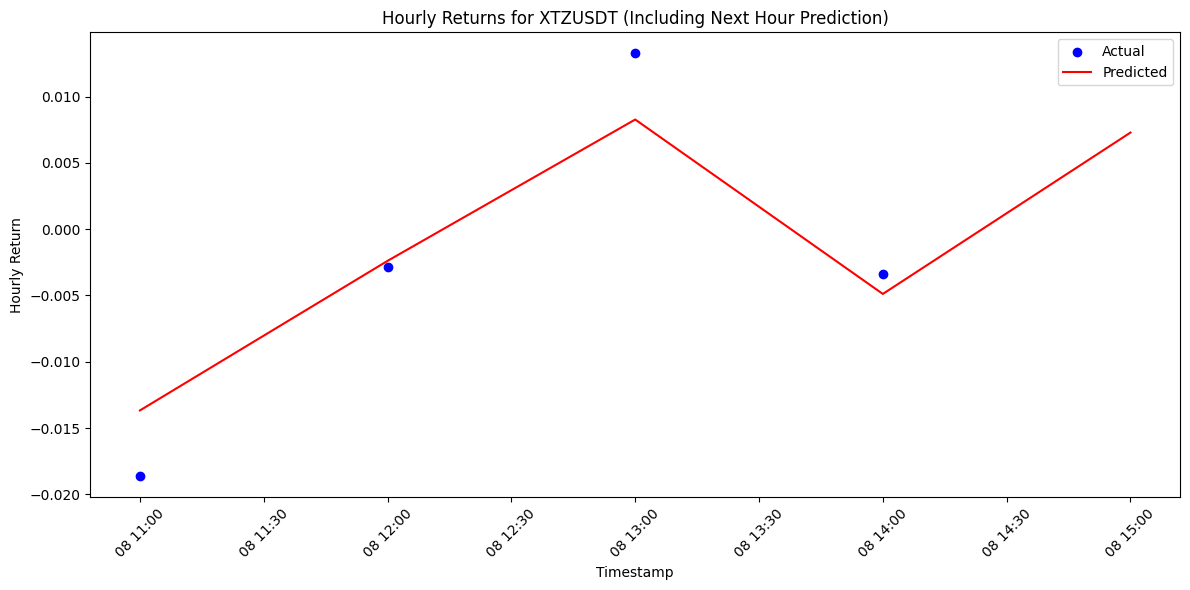

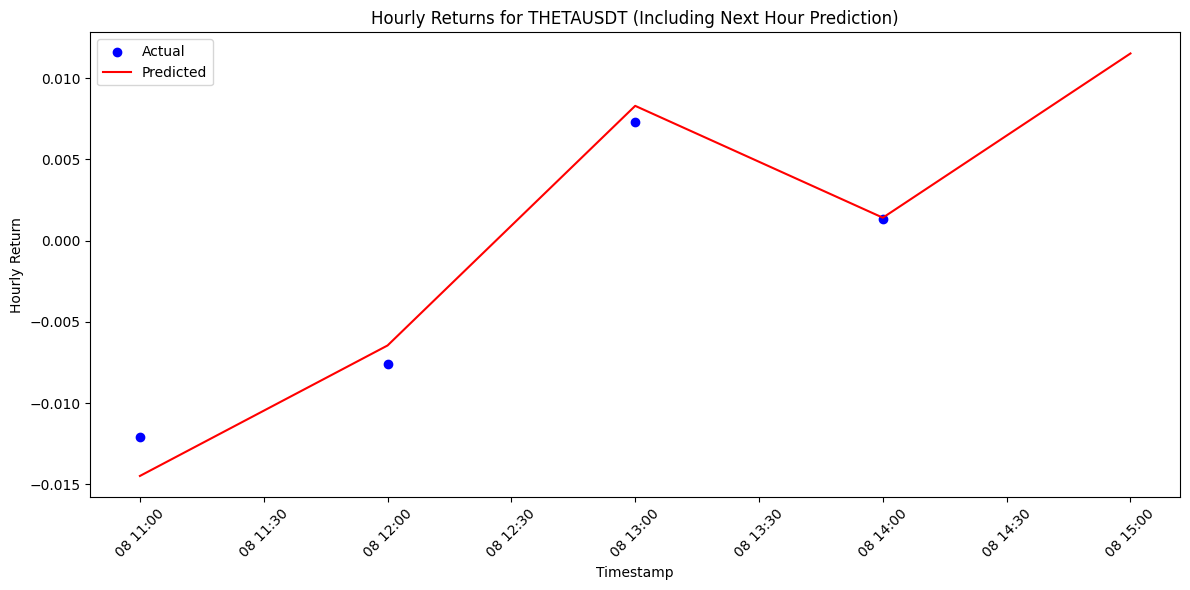

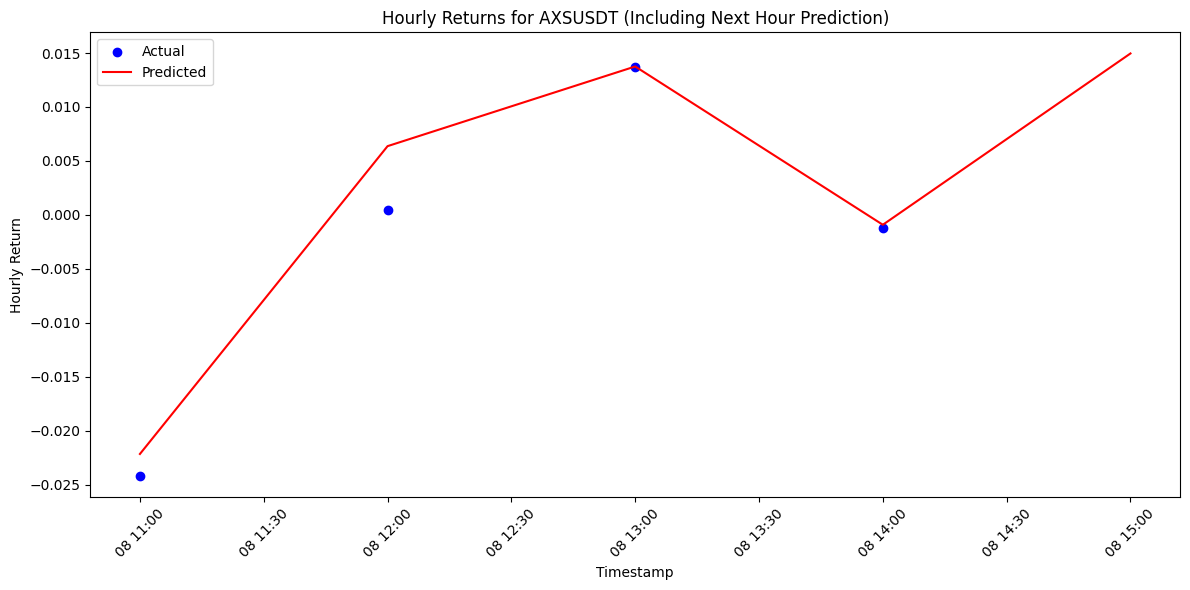

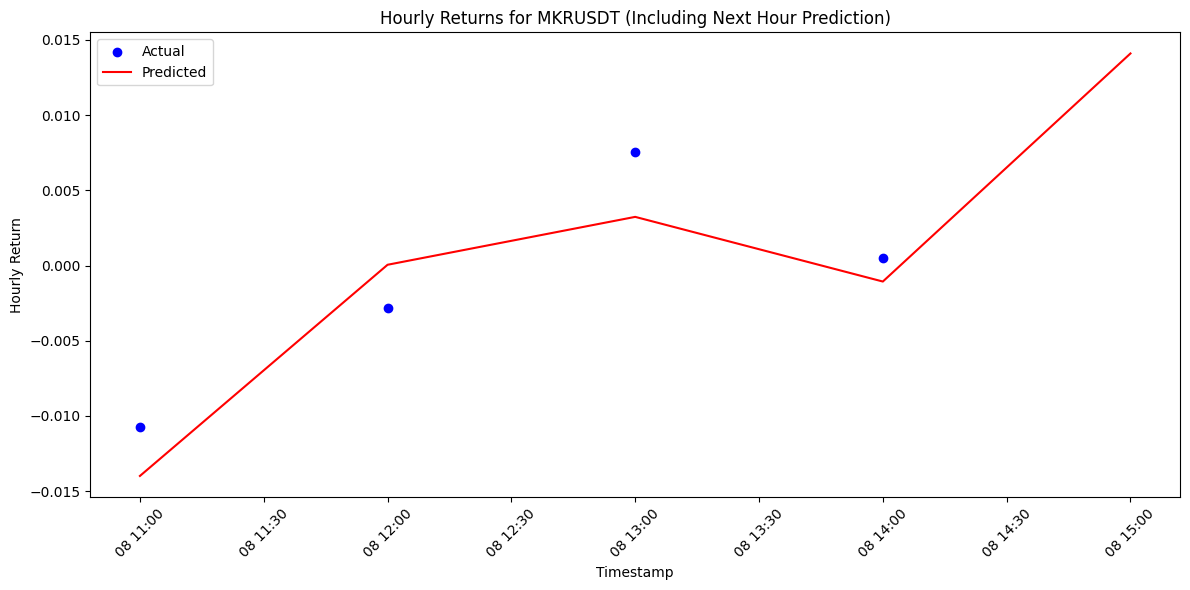

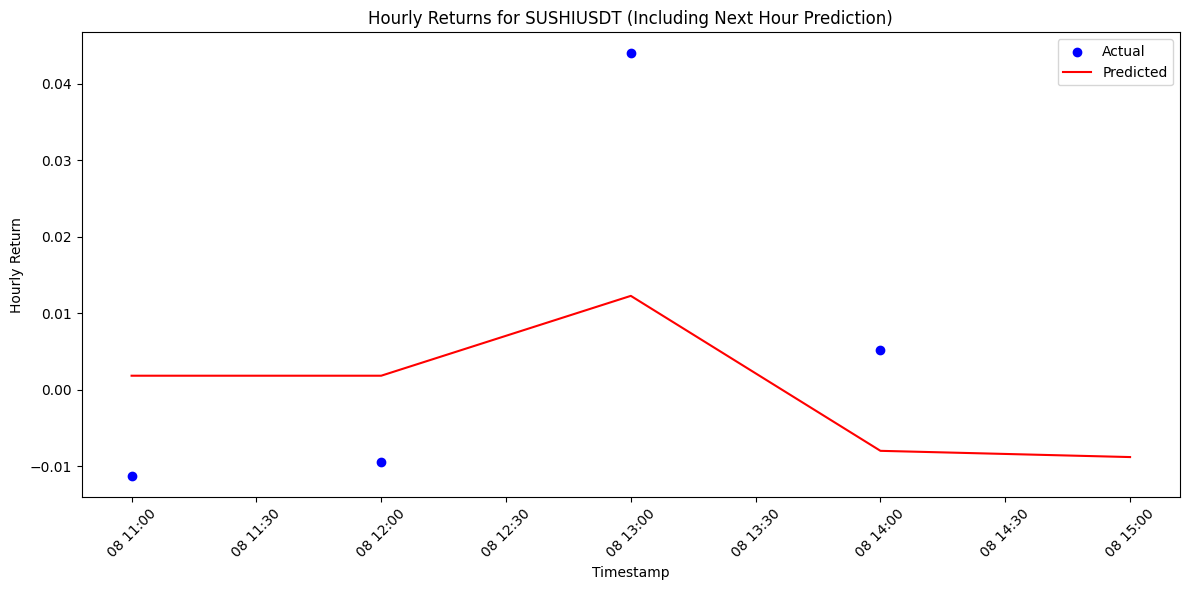

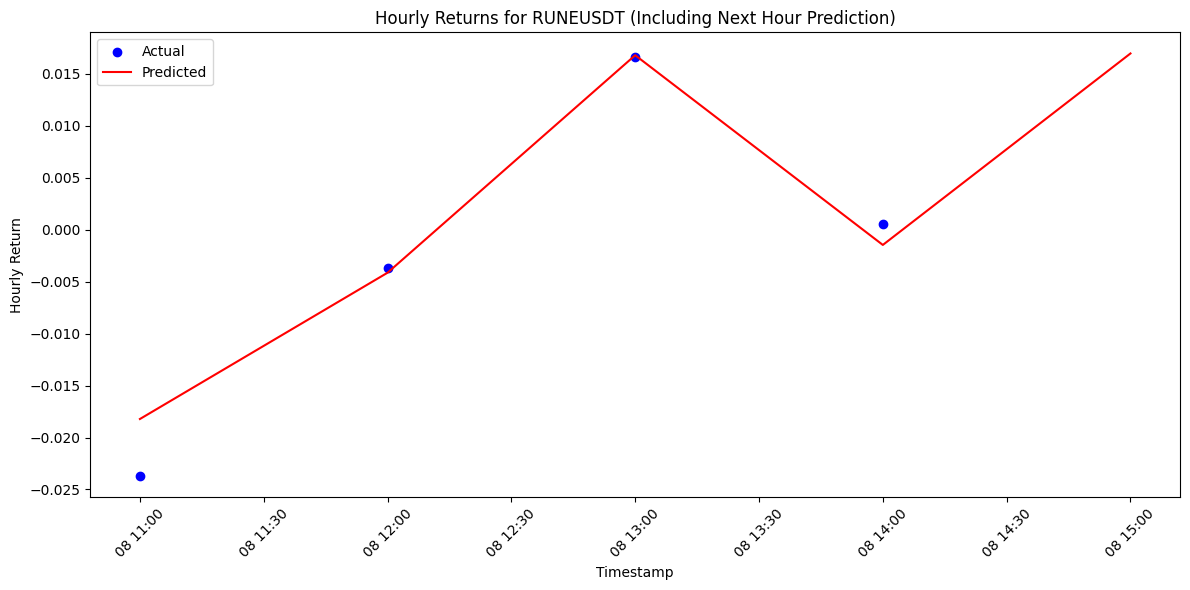

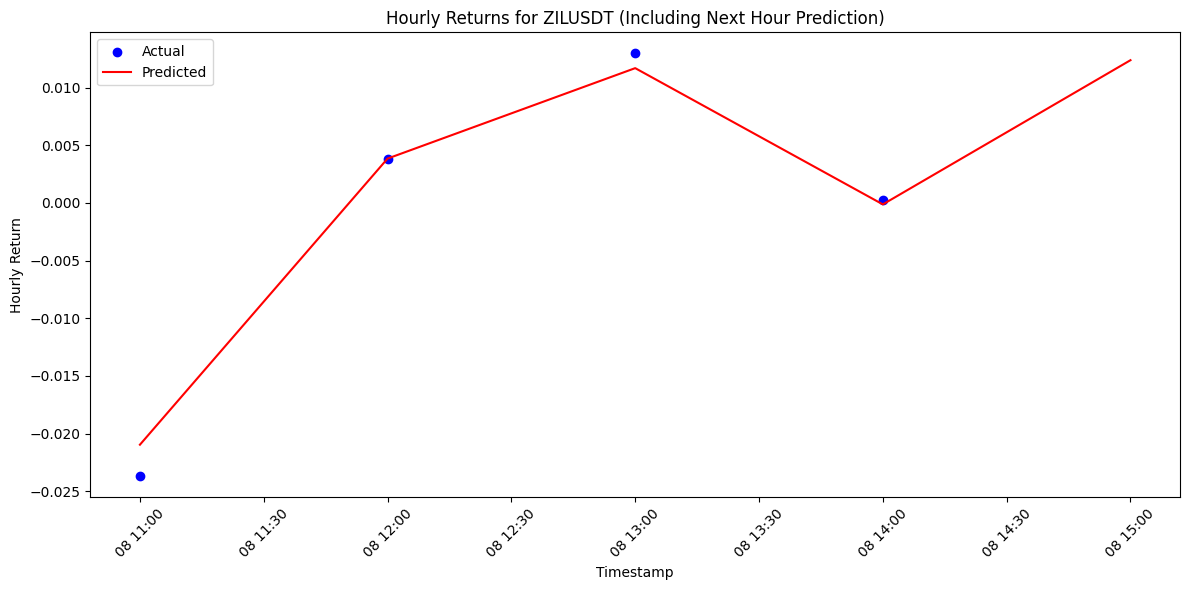

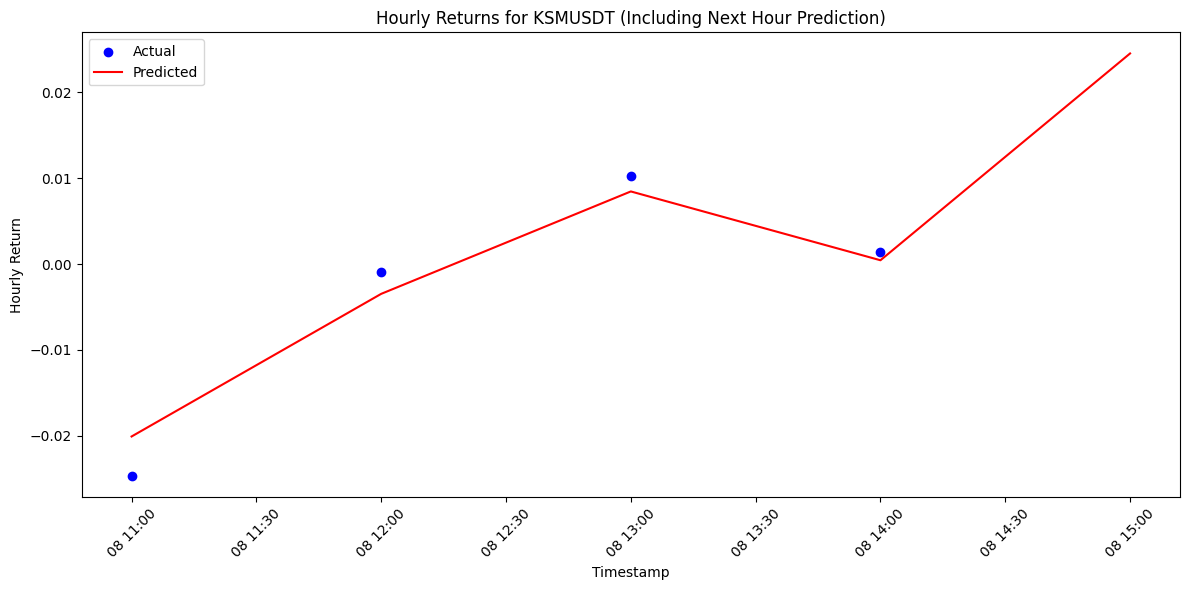

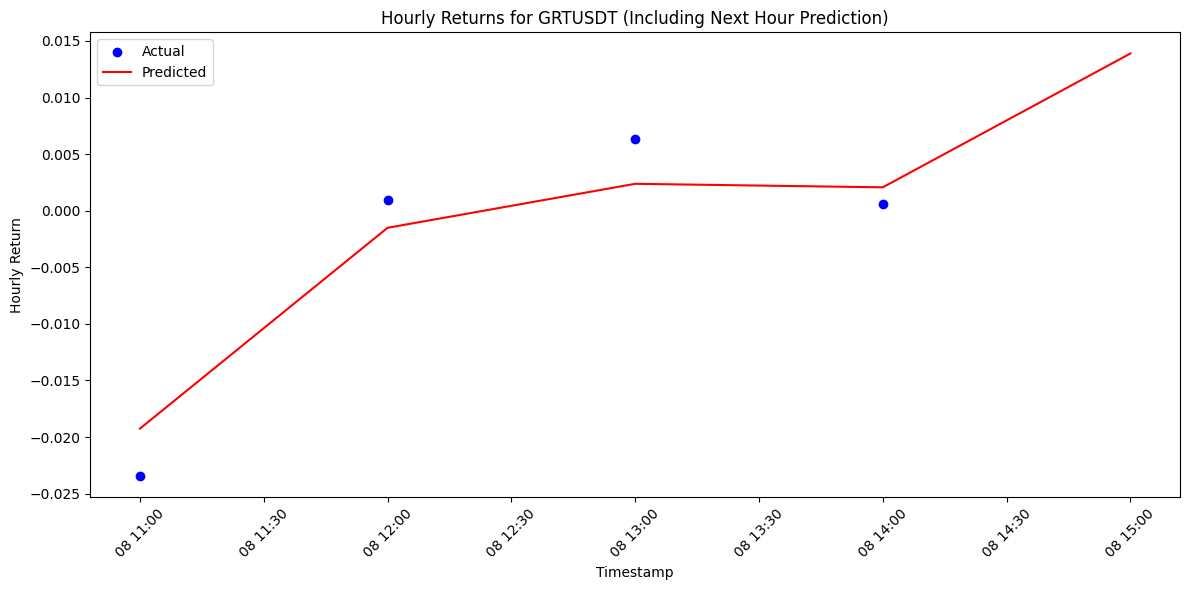

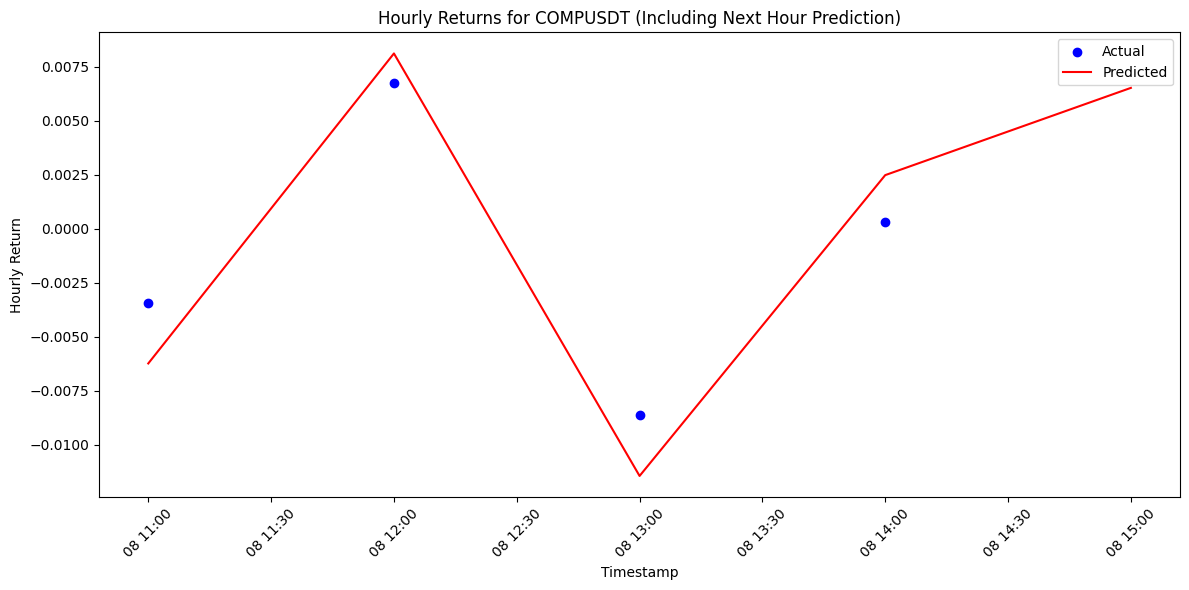

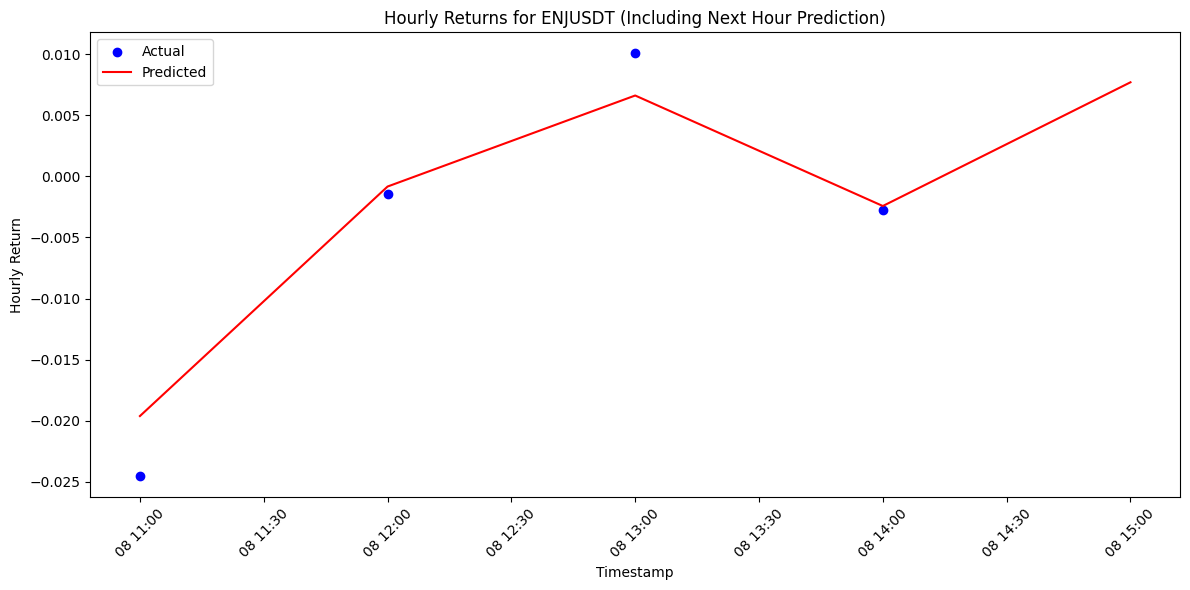

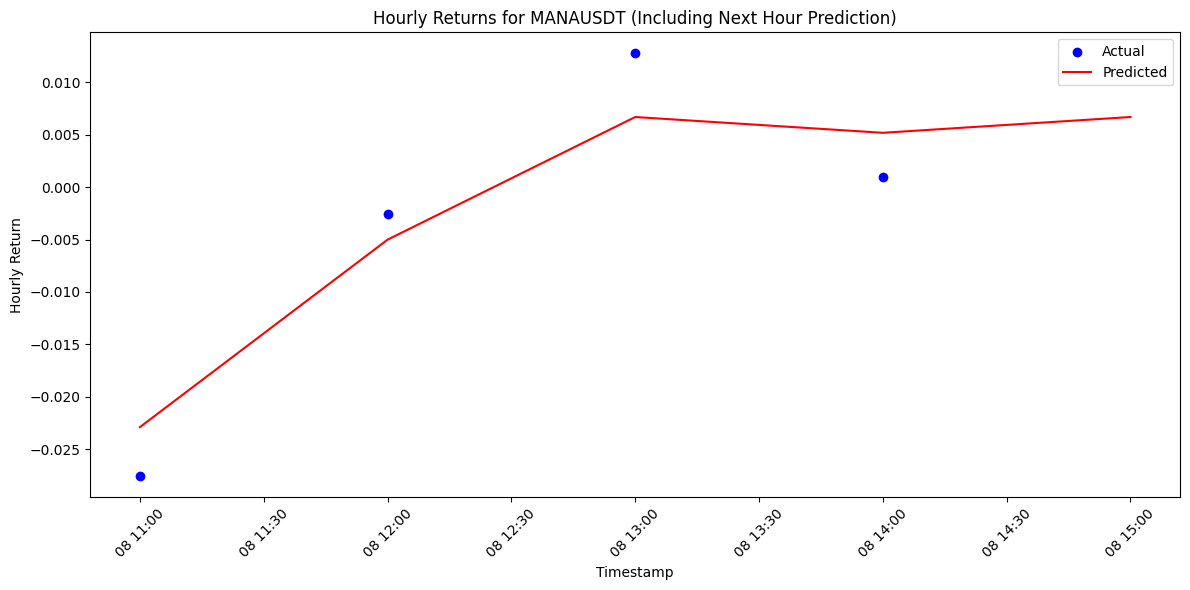

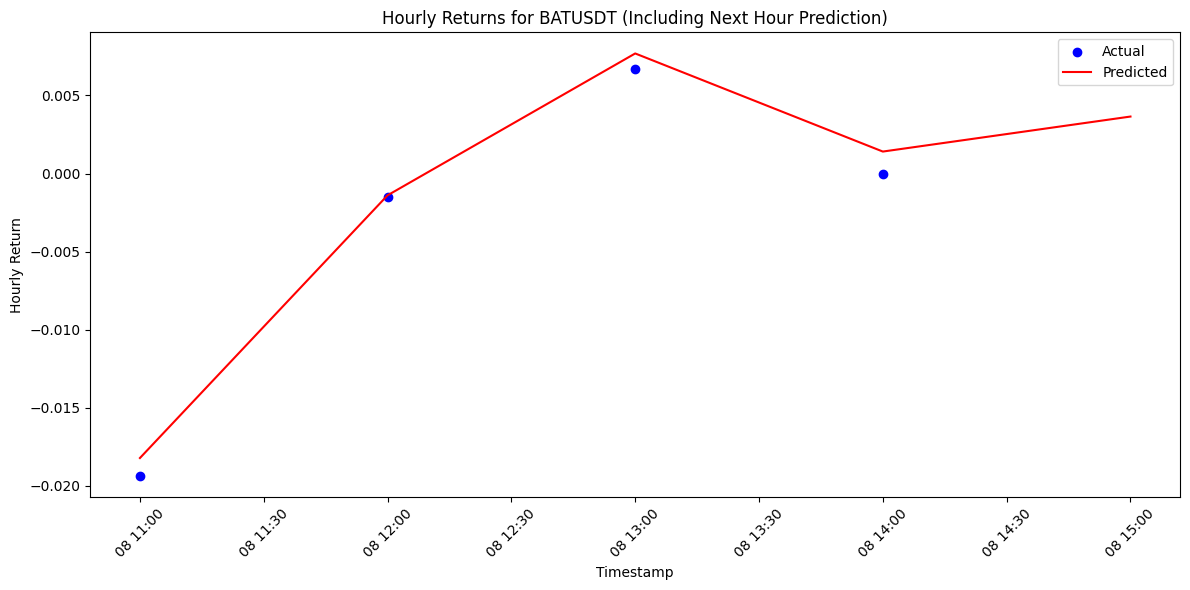

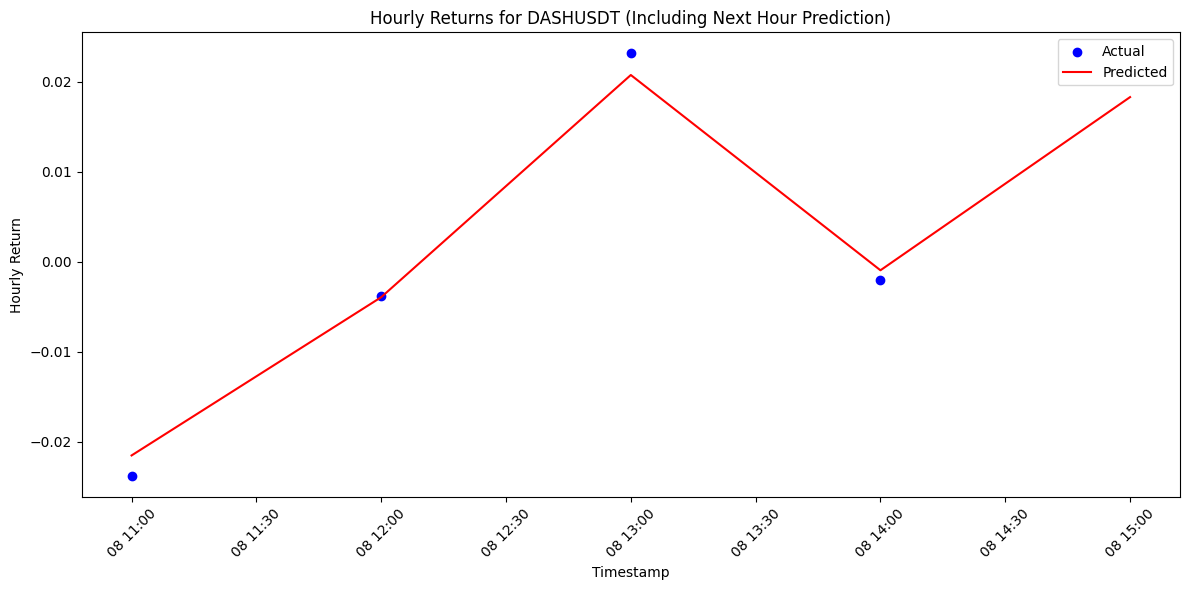

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

def prepare_data(data, symbol, features, target='Hourly_Return'):
    symbol_data = data[data['Symbol'] == symbol].copy()
    symbol_data = symbol_data.sort_index()

    symbol_data = symbol_data.dropna(subset=[target])
    symbol_data = symbol_data.replace([np.inf, -np.inf], np.nan).dropna(subset=[target])

    threshold = 1e6
    symbol_data = symbol_data[abs(symbol_data[target]) < threshold]

    X = symbol_data[features]
    y = symbol_data[target]

    return X, y

def train_and_predict(X, y, X_predict):
    model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X, y)
    return model.predict(X_predict)

# Features to use
features = ['Hour', 'Day', 'Volume', 'Month', 'DayOfWeek', 'Open', 'High', 'Low', 'Close']

# Get the latest timestamp in the dataset
latest_timestamp = df.index.max()

# Get all data up to and including the latest timestamp
train_data = df[df.index <= latest_timestamp]

# Get the last 3 hours of data
last_3_hours = df[df.index >= latest_timestamp - pd.Timedelta(hours=3)]

results = []

symbols = [
    'BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'ADAUSDT', 'DOGEUSDT',
    'XRPUSDT', 'DOTUSDT', 'UNIUSDT', 'LTCUSDT', 'LINKUSDT',
    'BCHUSDT', 'SOLUSDT', 'MATICUSDT', 'AVAXUSDT', 'XLMUSDT',
    'VETUSDT', 'TRXUSDT', 'FILUSDT', 'ETCUSDT', 'ALGOUSDT',
    'ATOMUSDT', 'FTTUSDT', 'ICPUSDT', 'EGLDUSDT', 'AAVEUSDT',
    'XTZUSDT', 'THETAUSDT', 'AXSUSDT', 'MKRUSDT',
    'SUSHIUSDT', 'RUNEUSDT', 'ZILUSDT', 'KSMUSDT', 'GRTUSDT',
    'COMPUSDT', 'ENJUSDT', 'MANAUSDT', 'BATUSDT', 'DASHUSDT'
]

for symbol in symbols:
    X, y = prepare_data(train_data, symbol, features)
    X_predict = last_3_hours[last_3_hours['Symbol'] == symbol][features]

    if not X_predict.empty:
        predictions = train_and_predict(X, y, X_predict)
        actual_values = last_3_hours[last_3_hours['Symbol'] == symbol]['Hourly_Return']

        for pred, actual, timestamp in zip(predictions, actual_values, X_predict.index):
            results.append({
                'Symbol': symbol,
                'Timestamp': timestamp,
                'Predicted': pred,
                'Actual': actual
            })

        # Predict the next hour
        next_hour = latest_timestamp + pd.Timedelta(hours=1)
        last_known_data = X_predict.iloc[-1]

        X_predict_next = pd.DataFrame(index=[next_hour], columns=features)
        X_predict_next['Hour'] = next_hour.hour
        X_predict_next['Day'] = next_hour.day
        X_predict_next['Month'] = next_hour.month
        X_predict_next['DayOfWeek'] = next_hour.dayofweek

        # Estimate next hour's features based on recent trends
        for feature in ['Volume', 'Open', 'High', 'Low', 'Close']:
            recent_values = X_predict[feature].values
            trend = recent_values[-1] - recent_values[0]
            X_predict_next[feature] = last_known_data[feature] + trend

        prediction_next = train_and_predict(X, y, X_predict_next)

        results.append({
            'Symbol': symbol,
            'Timestamp': next_hour,
            'Predicted': prediction_next[0],
            'Actual': np.nan  # No actual data for future prediction
        })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Sort the results by Symbol and Timestamp
results_df = results_df.sort_values(['Symbol', 'Timestamp'])

# Display the results
print(results_df[['Symbol', 'Timestamp', 'Predicted', 'Actual']].to_string(index=False))

# Plot results for each symbol
for symbol in symbols:
    symbol_results = results_df[results_df['Symbol'] == symbol]
    if not symbol_results.empty:
        plt.figure(figsize=(12, 6))
        plt.scatter(symbol_results['Timestamp'], symbol_results['Actual'], label='Actual', color='blue')
        plt.plot(symbol_results['Timestamp'], symbol_results['Predicted'], label='Predicted', color='red')

        # Highlight the new prediction point
        new_prediction = symbol_results[symbol_results['Timestamp'] == pd.Timestamp('2024-08-05 03:00:00')]
        if not new_prediction.empty:
            plt.scatter(new_prediction['Timestamp'], new_prediction['Predicted'], color='green', s=100, zorder=5, label='Next Hour Prediction')

        plt.title(f'Hourly Returns for {symbol} (Including Next Hour Prediction)')
        plt.xlabel('Timestamp')
        plt.ylabel('Hourly Return')
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

def prepare_data(data, symbol, features, target='Hourly_Return'):
    symbol_data = data[data['Symbol'] == symbol].copy()
    symbol_data = symbol_data.sort_index()
    symbol_data = symbol_data.dropna(subset=[target])
    symbol_data = symbol_data.replace([np.inf, -np.inf], np.nan).dropna(subset=[target])
    threshold = 1e6
    symbol_data = symbol_data[abs(symbol_data[target]) < threshold]
    X = symbol_data[features]
    y = symbol_data[target]
    return X, y

def train_and_predict(X, y, X_predict):
    model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X, y)
    return model.predict(X_predict)

# Features to use
features = ['Hour', 'Day', 'Volume', 'Month', 'DayOfWeek', 'Open', 'High', 'Low', 'Close']

# Get the latest timestamp in the dataset
latest_timestamp = df.index.max()

# Get all data up to and including the latest timestamp
train_data = df[df.index <= latest_timestamp]


# Get unique symbols
symbols = df['Symbol'].unique()

results = []

for symbol in symbols:
    X, y = prepare_data(train_data, symbol, features)

    # Calculate the next hour
    next_hour = latest_timestamp + pd.Timedelta(hours=1)
    last_known_data = train_data[train_data['Symbol'] == symbol].iloc[-1]

    X_predict_next = pd.DataFrame(index=[next_hour], columns=features)
    X_predict_next['Hour'] = next_hour.hour
    X_predict_next['Day'] = next_hour.day
    X_predict_next['Month'] = next_hour.month
    X_predict_next['DayOfWeek'] = next_hour.dayofweek

    # Estimate next hour's features based on recent trends
    window_size = 3  # Number of past hours to consider for trend calculation
    for feature in ['Volume', 'Open', 'High', 'Low', 'Close']:
        recent_values = train_data[train_data['Symbol'] == symbol][feature].values[-window_size:]
        trend = np.mean(np.diff(recent_values))  # Calculate average change
        X_predict_next[feature] = last_known_data[feature] + trend

    prediction_next = train_and_predict(X, y, X_predict_next)

    results.append({
        'Symbol': symbol,
        'Timestamp': next_hour,
        'Predicted': prediction_next[0],
        'Actual': np.nan  # No actual data for future prediction
    })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Sort the results by Symbol and Timestamp
results_df = results_df.sort_values(['Symbol', 'Timestamp'])

# Display the results
print(results_df[['Symbol', 'Timestamp', 'Predicted']].to_string(index=False))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000155 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1342
[LightGBM] [Info] Number of data points in the train set: 1646, number of used features: 9
[LightGBM] [Info] Start training from score 0.000284
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000060 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1342
[LightGBM] [Info] Number of data points in the train set: 1646, number of used features: 9
[LightGBM] [Info] Start training from score 0.000276
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000053 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1

###second chsssd

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

def prepare_data(data, symbol, features, target='Hourly_Return'):
    symbol_data = data[data['Symbol'] == symbol].copy()
    symbol_data = symbol_data.sort_index()
    symbol_data = symbol_data.dropna(subset=[target])
    symbol_data = symbol_data.replace([np.inf, -np.inf], np.nan).dropna(subset=[target])
    threshold = 1e6
    symbol_data = symbol_data[abs(symbol_data[target]) < threshold]
    X = symbol_data[features]
    y = symbol_data[target]
    return X, y

def train_and_predict(X, y, X_predict):
    model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X, y)
    return model.predict(X_predict)

# Features to use
features = ['Hour', 'Day', 'Volume', 'Month', 'DayOfWeek', 'Open', 'High', 'Low', 'Close']

# Get all data up to and including the latest timestamp
latest_timestamp = df.index.max()
train_data = df[df.index <= latest_timestamp]

# Get the last available hours in the dataset
last_hours = df[(df.index.date == latest_timestamp.date()) & (df.index.hour >= latest_timestamp.hour - 4)]

# List of symbols to process
symbols = df['Symbol'].unique()

results = []

for symbol in symbols:
    X, y = prepare_data(train_data, symbol, features)
    X_predict = last_hours[last_hours['Symbol'] == symbol][features]

    if not X_predict.empty:
        predictions = train_and_predict(X, y, X_predict)
        actual_values = last_hours[last_hours['Symbol'] == symbol]['Hourly_Return']

        for pred, actual, timestamp in zip(predictions, actual_values, X_predict.index):
            results.append({
                'Symbol': symbol,
                'Timestamp': timestamp,
                'Predicted': pred,
                'Actual': actual
            })

        # Predict the next hour after the latest timestamp
        next_hour = latest_timestamp + pd.Timedelta(hours=1)
        last_known_data = X_predict.iloc[-1]
        X_predict_next = pd.DataFrame(index=[next_hour], columns=features)
        X_predict_next['Hour'] = next_hour.hour
        X_predict_next['Day'] = next_hour.day
        X_predict_next['Month'] = next_hour.month
        X_predict_next['DayOfWeek'] = next_hour.dayofweek

        # Use last known values for other features
        # Estimate next hour's features based on recent trends
        window_size = 3  # Number of past hours to consider for trend calculation
        for feature in ['Volume', 'Open', 'High', 'Low', 'Close']:
            recent_values = X_predict[feature].values[-window_size:]
            trend = np.mean(np.diff(recent_values))  # Calculate average change
            X_predict_next[feature] = last_known_data[feature] + trend

        prediction_next = train_and_predict(X, y, X_predict_next)
        results.append({
            'Symbol': symbol,
            'Timestamp': next_hour,
            'Predicted': prediction_next[0],
            'Actual': np.nan  # No actual data for future prediction
        })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Sort the results by Symbol and Timestamp
results_df = results_df.sort_values(['Symbol', 'Timestamp'])

# Display the results
print(results_df[['Symbol', 'Timestamp', 'Predicted', 'Actual']].to_string(index=False))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1342
[LightGBM] [Info] Number of data points in the train set: 1646, number of used features: 9
[LightGBM] [Info] Start training from score 0.000284
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1342
[LightGBM] [Info] Number of data points in the train set: 1646, number of used features: 9
[LightGBM] [Info] Start training from score 0.000284
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000057 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, y

Symbol: BTCUSDT, Last 5 hours data shape: (6, 12)
                      Symbol      Open      High       Low     Close  \
Timestamp                                                              
2024-12-08 09:00:00  BTCUSDT  99534.26  99803.32  99336.00  99675.96   
2024-12-08 10:00:00  BTCUSDT  99675.97  99863.35  99632.61  99675.11   
2024-12-08 11:00:00  BTCUSDT  99675.11  99687.85  98964.00  98980.01   
2024-12-08 12:00:00  BTCUSDT  98980.02  99300.00  98657.70  98884.02   
2024-12-08 13:00:00  BTCUSDT  98884.03  99409.02  98876.00  99249.22   

                        Volume  Hourly_Return  Hour  Day  Month  DayOfWeek  \
Timestamp                                                                    
2024-12-08 09:00:00  397.06249       0.001424     9    8     12          6   
2024-12-08 10:00:00  278.48465      -0.000009    10    8     12          6   
2024-12-08 11:00:00  668.22137      -0.006974    11    8     12          6   
2024-12-08 12:00:00  890.41696      -0.000970    12    

<ipython-input-6-d87ef7deff02>:104: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = results_df.groupby('Symbol').apply(lambda x: {


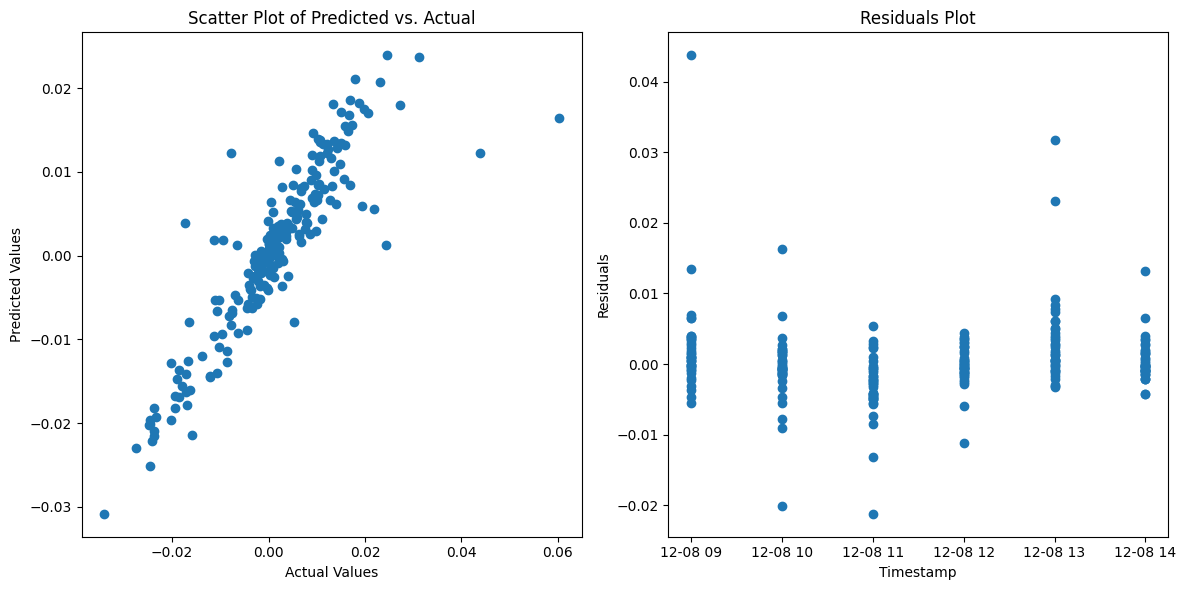

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt


def prepare_data(data, symbol, features, target='Hourly_Return'):
    symbol_data = data[data['Symbol'] == symbol].copy()
    symbol_data = symbol_data.sort_index()

    symbol_data = symbol_data.dropna(subset=[target])
    symbol_data = symbol_data.replace([np.inf, -np.inf], np.nan).dropna(subset=[target])

    threshold = 1e6
    symbol_data = symbol_data[abs(symbol_data[target]) < threshold]

    X = symbol_data[features]
    y = symbol_data[target]

    return X, y

def train_and_predict(X, y, X_predict):
    model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X, y)
    return model.predict(X_predict)

# Features to use
features = ['Hour', 'Day', 'Volume', 'Month', 'DayOfWeek', 'Open', 'High', 'Low', 'Close']

# Get the latest timestamp in the dataset
latest_timestamp = df.index.max()

# Get the last 5 hours of data
last_5_hours = df[(df.index >= latest_timestamp - pd.Timedelta(hours=5)) & (df.index <= latest_timestamp)]
# Check data availability for each symbol
for symbol in symbols:
    symbol_data = last_5_hours[last_5_hours['Symbol'] == symbol]
    print(f"Symbol: {symbol}, Last 5 hours data shape: {symbol_data.shape}")
    if not symbol_data.empty:
        print(symbol_data.head())

results = []

for symbol in symbols:
    X, y = prepare_data(df, symbol, features)

    # Debugging: Print shape of X and y
    print(f"Symbol: {symbol}, X shape: {X.shape}, y shape: {y.shape}")

    # Get the last 5 hours data for this symbol
    X_predict = last_5_hours[last_5_hours['Symbol'] == symbol][features]

    # Debugging: Print shape of X_predict
    print(f"Symbol: {symbol}, X_predict shape: {X_predict.shape}")

    if not X_predict.empty:
        predictions = train_and_predict(X, y, X_predict)
        actual_values = last_5_hours[last_5_hours['Symbol'] == symbol]['Hourly_Return']

        for pred, actual, timestamp in zip(predictions, actual_values, X_predict.index):
            results.append({
                'Symbol': symbol,
                'Timestamp': timestamp,
                'Predicted': pred,
                'Actual': actual
            })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Debugging: Print results_df to check contents
print("\nResults DataFrame:")
print(results_df.head())

# Sort the results by Symbol and Timestamp
results_df = results_df.sort_values(['Symbol', 'Timestamp'])

# Display the results
print(results_df.to_string(index=False))

# Calculate overall metrics
mse = mean_squared_error(results_df['Actual'], results_df['Predicted'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(results_df['Actual'], results_df['Predicted'])
r2 = r2_score(results_df['Actual'], results_df['Predicted'])

print("\nOverall Metrics:")
print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R2: {r2:.6f}")

# Calculate metrics for each symbol
symbol_metrics = results_df.groupby('Symbol').agg({
    'Predicted': ['mean', 'std'],
    'Actual': ['mean', 'std']
}).reset_index()

symbol_metrics.columns = ['Symbol', 'Predicted_Mean', 'Predicted_Std', 'Actual_Mean', 'Actual_Std']
print("\nMetrics by Symbol:")
print(symbol_metrics.to_string())

grouped = results_df.groupby('Symbol').apply(lambda x: {
    'MAE': mean_absolute_error(x['Actual'], x['Predicted']),
    'MSE': mean_squared_error(x['Actual'], x['Predicted']),
    'RMSE': np.sqrt(mean_squared_error(x['Actual'], x['Predicted'])),
    'MAPE': np.mean(np.abs((x['Actual'] - x['Predicted']) / x['Actual'])) * 100
})

print(grouped)


plt.figure(figsize=(12, 6))

# Scatter Plot
plt.subplot(1, 2, 1)
plt.scatter(results_df['Actual'], results_df['Predicted'])
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Scatter Plot of Predicted vs. Actual')

# Residual Plot
plt.subplot(1, 2, 2)
residuals = results_df['Actual'] - results_df['Predicted']
plt.scatter(results_df['Timestamp'], residuals)
plt.xlabel('Timestamp')
plt.ylabel('Residuals')
plt.title('Residuals Plot')

plt.tight_layout()
plt.show()



# Newly added

['BTCUSDT' 'ETHUSDT' 'BNBUSDT' 'ADAUSDT' 'DOGEUSDT' 'XRPUSDT' 'DOTUSDT'
 'UNIUSDT' 'LTCUSDT' 'LINKUSDT' 'BCHUSDT' 'SOLUSDT' 'AVAXUSDT' 'XLMUSDT'
 'VETUSDT' 'TRXUSDT' 'FILUSDT' 'ETCUSDT' 'ALGOUSDT' 'ATOMUSDT' 'FTTUSDT'
 'ICPUSDT' 'EGLDUSDT' 'AAVEUSDT' 'XTZUSDT' 'THETAUSDT' 'AXSUSDT' 'MKRUSDT'
 'SUSHIUSDT' 'RUNEUSDT' 'ZILUSDT' 'KSMUSDT' 'GRTUSDT' 'COMPUSDT' 'ENJUSDT'
 'MANAUSDT' 'BATUSDT' 'DASHUSDT']


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Multivariate RMSE: 0.0076749912913060365
Mean Absolute Error (MAE): 0.006049689091987711
Mean Squared Error (MSE): 5.89054913216235e-05
R-squared (R2): -0.8349905638770125
                       Actual  Predicted  Difference
2024-11-24 21:00:00  0.006618  -0.001662    0.008281
2024-11-24 22:00:00 -0.002253  -0.005433    0.003180
2024-11-24 23:00:00  0.005258  -0.001997    0.007255
2024-11-25 00:00:00  0.001533  -0.001378    0.002910
2024-11-25 01:00:00  0.010571  -0.005141    0.015711


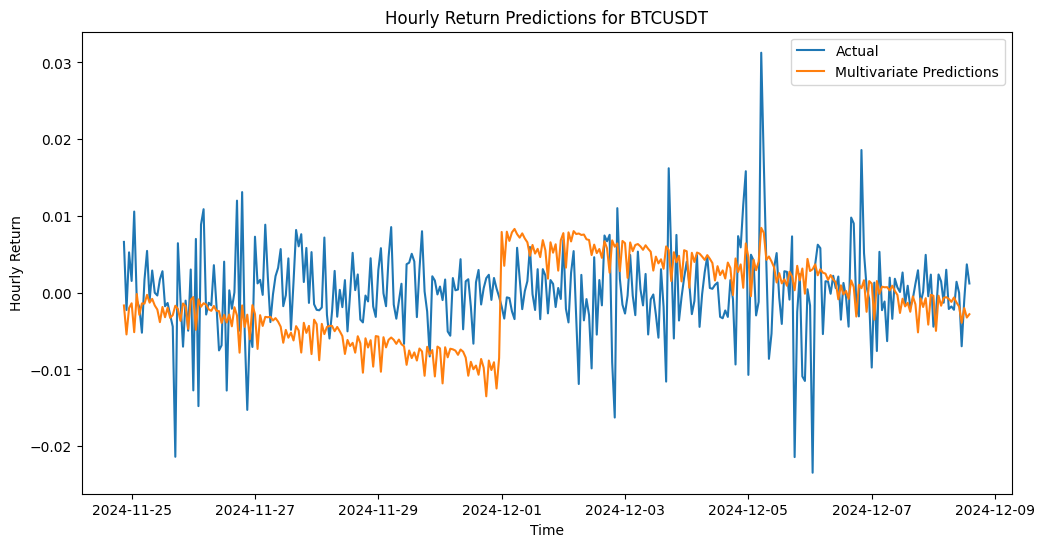

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with the preprocessed data

def multivariate_modeling(data, symbol, exog_features):
    # Filter data for a specific symbol
    symbol_data = data[data['Symbol'] == symbol].dropna(subset=['Hourly_Return'])  # Drop rows with NaN in 'Hourly_Return'
    # Check if the filtered DataFrame is empty
    if symbol_data.empty:
        print(f"No data found for symbol: {symbol}")
        return None, None, None, None
    # Prepare exogenous variables
    exog = symbol_data[exog_features]
    endog = symbol_data['Hourly_Return']
    # Split data into train and test
    train_size = int(len(endog) * 0.8)
    train_endog, test_endog = endog[:train_size], endog[train_size:]
    train_exog, test_exog = exog.iloc[:train_size], exog.iloc[train_size:]
    # Fit SARIMAX model
    model = SARIMAX(train_endog, exog=train_exog, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    # Make predictions
    predictions = model_fit.forecast(steps=len(test_endog), exog=test_exog)  # Use test_exog for predictions
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(test_endog, predictions))
    return rmse, predictions, test_endog, predictions

# Select top features based on importance
top_features = ['Hour', 'Day', 'Volume', 'Month', 'DayOfWeek']

# Example usage
# Check for available symbols and choose one
print(df['Symbol'].unique())  # Print unique symbols in your DataFrame
symbol_to_predict = 'BTCUSDT'  # Replace 'YOUR_SYMBOL' with an available symbol from the list above

# Multivariate modeling
multi_rmse, multi_predictions, actual_values, predicted_values = multivariate_modeling(df, symbol_to_predict, top_features)

# Check if predictions were made before printing and plotting
if multi_predictions is not None:
    print(f"Multivariate RMSE: {multi_rmse}")

    # Create a DataFrame for actual vs predicted values
    actual_vs_predicted = pd.DataFrame({
        'Actual': actual_values.values,
        'Predicted': predicted_values
    })

    # Calculate differences
    actual_vs_predicted['Difference'] = actual_vs_predicted['Actual'] - actual_vs_predicted['Predicted']

    # Calculate accuracy metrics
    mae = mean_absolute_error(actual_vs_predicted['Actual'], actual_vs_predicted['Predicted'])
    mse = mean_squared_error(actual_vs_predicted['Actual'], actual_vs_predicted['Predicted'])
    r2 = r2_score(actual_vs_predicted['Actual'], actual_vs_predicted['Predicted'])

    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"R-squared (R2): {r2}")

    # Display the first few rows of the DataFrame
    print(actual_vs_predicted.head())

    # Optionally, save to a CSV file
    actual_vs_predicted.to_csv('actual_vs_predicted.csv', index=False)

    # Plot results
    plt.figure(figsize=(12, 6))
    plt.plot(actual_vs_predicted['Actual'], label='Actual')
    plt.plot(actual_vs_predicted['Predicted'], label='Multivariate Predictions')
    plt.title(f'Hourly Return Predictions for {symbol_to_predict}')
    plt.xlabel('Time')
    plt.ylabel('Hourly Return')
    plt.legend()
    plt.show()
else:
    print(f"No predictions could be made for {symbol_to_predict}. Please check if data is available.")



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000193 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1341
[LightGBM] [Info] Number of data points in the train set: 1316, number of used features: 9
[LightGBM] [Info] Start training from score 0.000324
Model Evaluation:

XGBoost:
  MSE: 0.000028
  RMSE: 0.005257
  MAE: 0.003720
  R2: 0.138958

LightGBM:
  MSE: 0.000027
  RMSE: 0.005154
  MAE: 0.003472
  R2: 0.172508

Random Forest:
  MSE: 0.000034
  RMSE: 0.005799
  MAE: 0.004000
  R2: -0.047711

Best Model: LightGBM


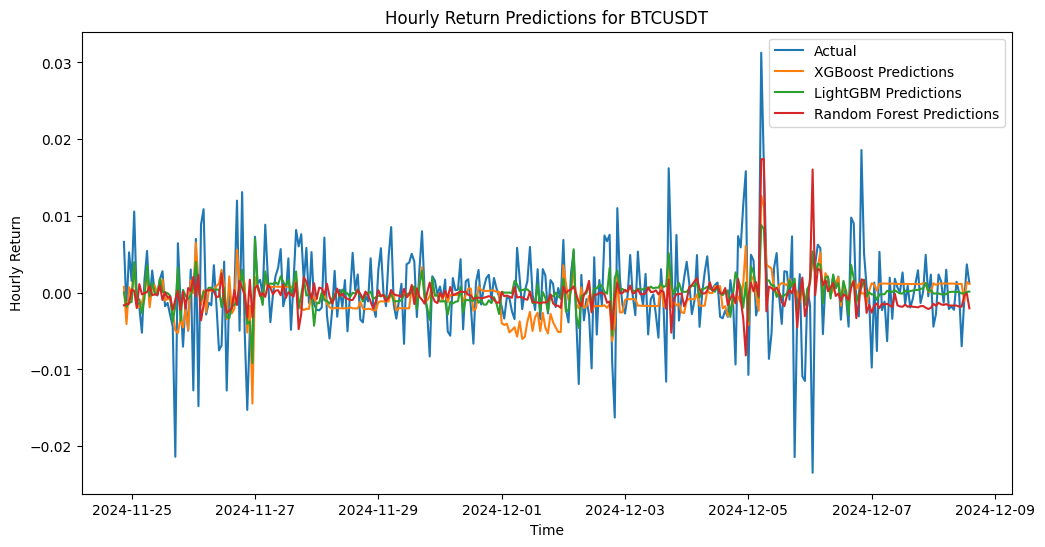


Feature Importance:
     feature  importance
5       Open         949
8      Close         870
2     Volume         697
0       Hour         186
1        Day         102
7        Low          82
6       High          63
4  DayOfWeek          51
3      Month           0


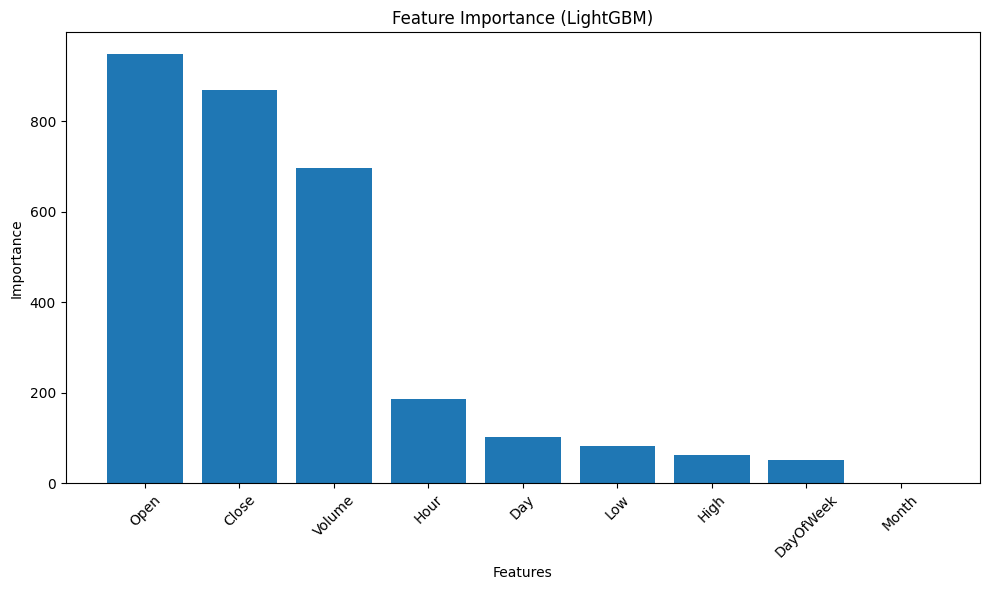

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with the preprocessed data
def prepare_data(data, symbol, features, target='Hourly_Return'):
    symbol_data = data[data['Symbol'] == symbol].copy()
    symbol_data = symbol_data.sort_index()

    # Handle NaN values in the target variable
    symbol_data = symbol_data.dropna(subset=[target])

    # Handle infinity values
    symbol_data = symbol_data.replace([np.inf, -np.inf], np.nan).dropna(subset=[target])

    # Handle extremely large values (you may need to adjust the threshold)
    threshold = 1e6  # Adjust this value based on what's reasonable for your data
    symbol_data = symbol_data[abs(symbol_data[target]) < threshold]

    X = symbol_data[features]
    y = symbol_data[target]

    return train_test_split(X, y, test_size=0.2, shuffle=False)

# Use this updated function in your main code
X_train, X_test, y_train, y_test = prepare_data(df, symbol_to_predict, features)

def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

def plot_results(y_true, predictions, title):
    plt.figure(figsize=(12, 6))
    plt.plot(y_true.index, y_true.values, label='Actual')
    for model, pred in predictions.items():
        plt.plot(y_true.index, pred, label=f'{model} Predictions')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Hourly Return')
    plt.legend()
    plt.show()

# Select features based on importance
features = ['Hour', 'Day', 'Volume', 'Month', 'DayOfWeek', 'Open', 'High', 'Low', 'Close']

# Example usage
symbol_to_predict = 'BTCUSDT'  # Replace with the symbol you want to predict

# Prepare data
X_train, X_test, y_train, y_test = prepare_data(df, symbol_to_predict, features)

# Recipe 4-2: XGBoost Model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_eval = evaluate_model(y_test, xgb_pred)

# Recipe 4-3: LightGBM Model
lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
lgbm_model.fit(X_train, y_train)
lgbm_pred = lgbm_model.predict(X_test)
lgbm_eval = evaluate_model(y_test, lgbm_pred)

# Recipe 4-4: Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_eval = evaluate_model(y_test, rf_pred)

# Recipe 4-5: Selecting the Best Model
models = {
    'XGBoost': (xgb_model, xgb_pred, xgb_eval),
    'LightGBM': (lgbm_model, lgbm_pred, lgbm_eval),
    'Random Forest': (rf_model, rf_pred, rf_eval)
}

best_model = min(models, key=lambda x: models[x][2]['RMSE'])

print("Model Evaluation:")
for model, (_, _, eval_metrics) in models.items():
    print(f"\n{model}:")
    for metric, value in eval_metrics.items():
        print(f"  {metric}: {value:.6f}")

print(f"\nBest Model: {best_model}")

# Plot results
plot_results(y_test, {model: pred for model, (_, pred, _) in models.items()},
             f'Hourly Return Predictions for {symbol_to_predict}')

# Feature Importance
best_model_obj = models[best_model][0]
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': best_model_obj.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.title(f'Feature Importance ({best_model})')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chatggs

# Clauddd

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor

def prepare_data(data, symbol, features, target='Hourly_Return'):
    symbol_data = data[data['Symbol'] == symbol].copy()
    symbol_data = symbol_data.sort_index()

    symbol_data = symbol_data.dropna(subset=[target])
    symbol_data = symbol_data.replace([np.inf, -np.inf], np.nan).dropna(subset=[target])

    threshold = 1e6
    symbol_data = symbol_data[abs(symbol_data[target]) < threshold]

    X = symbol_data[features]
    y = symbol_data[target]

    return X, y

def train_and_predict(X, y, X_predict):
    model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X, y)
    return model.predict(X_predict)

# Features to use
features = ['Hour', 'Day', 'Volume', 'Month', 'DayOfWeek', 'Open', 'High', 'Low', 'Close']

results = []

for symbol in df['Symbol'].unique():
    X, y = prepare_data(df, symbol, features)

    # Get the latest timestamp for this symbol
    latest_timestamp = df[df['Symbol'] == symbol].index.max()

    # Calculate the next hour
    next_hour = latest_timestamp + pd.Timedelta(hours=1)

    # Create a DataFrame for the next hour
    X_predict_next = pd.DataFrame(index=[next_hour], columns=features)
    X_predict_next['Hour'] = next_hour.hour
    X_predict_next['Day'] = next_hour.day
    X_predict_next['Month'] = next_hour.month
    X_predict_next['DayOfWeek'] = next_hour.dayofweek
# Estimate next hour's features based on recent trends
    window_size = 3  # Number of past hours to consider for trend calculation
    for feature in ['Volume', 'Open', 'High', 'Low', 'Close']:
        recent_values = df[df['Symbol'] == symbol][feature].values[-window_size:]
        trend = np.mean(np.diff(recent_values))  # Calculate average change
        X_predict_next[feature] = df[df['Symbol'] == symbol][feature].iloc[-1] + trend

    prediction_next = train_and_predict(X, y, X_predict_next)

    results.append({
        'Symbol': symbol,
        'Timestamp': next_hour,
        'Predicted': prediction_next[0]
    })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Sort the results by Symbol and Timestamp
results_df = results_df.sort_values(['Symbol', 'Timestamp'])

# Display the results
print(results_df.to_string(index=False))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000057 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1342
[LightGBM] [Info] Number of data points in the train set: 1646, number of used features: 9
[LightGBM] [Info] Start training from score 0.000284
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000055 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1342
[LightGBM] [Info] Number of data points in the train set: 1646, number of used features: 9
[LightGBM] [Info] Start training from score 0.000276
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000055 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, y

# All data Training added on Saturday 7th September

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

def prepare_data(data, symbol, features, target='Hourly_Return'):
    symbol_data = data[data['Symbol'] == symbol].copy()
    symbol_data = symbol_data.sort_index()

    symbol_data = symbol_data.dropna(subset=[target])
    symbol_data = symbol_data.replace([np.inf, -np.inf], np.nan).dropna(subset=[target])

    threshold = 1e6
    symbol_data = symbol_data[abs(symbol_data[target]) < threshold]

    X = symbol_data[features]
    y = symbol_data[target]

    return X, y

def train_and_predict(X, y, X_predict):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    return model.predict(X_predict)

# Read the CSV file
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/crypto_hourly_prices_2024.csv")

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Set Timestamp as index
df.set_index('Timestamp', inplace=True)

# Calculate hourly returns
df['Hourly_Return'] = df.groupby('Symbol')['Close'].pct_change()

# Extract time-based features
df['Hour'] = df.index.hour
df['Day'] = df.index.day
df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek

# Features to use
features = ['Hour', 'Day', 'Volume', 'Month', 'DayOfWeek', 'Open', 'High', 'Low', 'Close']

results = []

for symbol in df['Symbol'].unique():
    X, y = prepare_data(df, symbol, features)

    # Get the latest timestamp for this symbol
    latest_timestamp = df[df['Symbol'] == symbol].index.max()

    # Calculate the next hour
    next_hour = latest_timestamp + pd.Timedelta(hours=1)

    # Create a DataFrame for the next hour
    X_predict_next = pd.DataFrame(index=[next_hour], columns=features)
    X_predict_next['Hour'] = next_hour.hour
    X_predict_next['Day'] = next_hour.day
    X_predict_next['Month'] = next_hour.month
    X_predict_next['DayOfWeek'] = next_hour.dayofweek

    # Estimate next hour's features based on recent trends
    window_size = 3  # Number of past hours to consider for trend calculation
    for feature in ['Volume', 'Open', 'High', 'Low', 'Close']:
        recent_values = df[df['Symbol'] == symbol][feature].values[-window_size:]
        trend = np.mean(np.diff(recent_values))  # Calculate average change
        X_predict_next[feature] = df[df['Symbol'] == symbol][feature].iloc[-1] + trend

    prediction_next = train_and_predict(X, y, X_predict_next)

    # Round the prediction to 6 decimal places
    rounded_prediction = round(prediction_next[0], 6)

    results.append({
        'Symbol': symbol,
        'Timestamp': next_hour,
        'Predicted': rounded_prediction
    })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Sort the results by Symbol and Timestamp
results_df = results_df.sort_values(['Symbol', 'Timestamp'])

# Display the results
print(results_df.to_string(index=False))

   Symbol           Timestamp  Predicted
 AAVEUSDT 2024-12-08 15:00:00   0.002104
  ADAUSDT 2024-12-08 15:00:00   0.000261
 ALGOUSDT 2024-12-08 15:00:00  -0.008984
 ATOMUSDT 2024-12-08 15:00:00  -0.007008
 AVAXUSDT 2024-12-08 15:00:00  -0.001104
  AXSUSDT 2024-12-08 15:00:00   0.000358
  BATUSDT 2024-12-08 15:00:00   0.001853
  BCHUSDT 2024-12-08 15:00:00   0.001185
  BNBUSDT 2024-12-08 15:00:00   0.002242
  BTCUSDT 2024-12-08 15:00:00   0.000420
 COMPUSDT 2024-12-08 15:00:00  -0.002032
 DASHUSDT 2024-12-08 15:00:00   0.000589
 DOGEUSDT 2024-12-08 15:00:00   0.001321
  DOTUSDT 2024-12-08 15:00:00   0.000269
 EGLDUSDT 2024-12-08 15:00:00  -0.004590
  ENJUSDT 2024-12-08 15:00:00  -0.001049
  ETCUSDT 2024-12-08 15:00:00   0.002257
  ETHUSDT 2024-12-08 15:00:00   0.001512
  FILUSDT 2024-12-08 15:00:00   0.003597
  FTTUSDT 2024-12-08 15:00:00  -0.000416
  GRTUSDT 2024-12-08 15:00:00   0.001447
  ICPUSDT 2024-12-08 15:00:00  -0.002173
  KSMUSDT 2024-12-08 15:00:00   0.003595
 LINKUSDT 2024-1

# Grouped

Symbol: BTCUSDT, Last 5 hours data shape: (6, 11)
                      Symbol      Open      High       Low     Close  \
Timestamp                                                              
2024-12-08 09:00:00  BTCUSDT  99534.26  99803.32  99336.00  99675.96   
2024-12-08 10:00:00  BTCUSDT  99675.97  99863.35  99632.61  99675.11   
2024-12-08 11:00:00  BTCUSDT  99675.11  99687.85  98964.00  98980.01   
2024-12-08 12:00:00  BTCUSDT  98980.02  99300.00  98657.70  98884.02   
2024-12-08 13:00:00  BTCUSDT  98884.03  99409.02  98876.00  99249.22   

                        Volume  Hourly_Return  Hour  Day  Month  DayOfWeek  
Timestamp                                                                   
2024-12-08 09:00:00  397.06249       0.001424     9    8     12          6  
2024-12-08 10:00:00  278.48465      -0.000009    10    8     12          6  
2024-12-08 11:00:00  668.22137      -0.006974    11    8     12          6  
2024-12-08 12:00:00  890.41696      -0.000970    12    8    

<ipython-input-11-056697cbf9d2>:105: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = results_df.groupby('Symbol').apply(lambda x: {


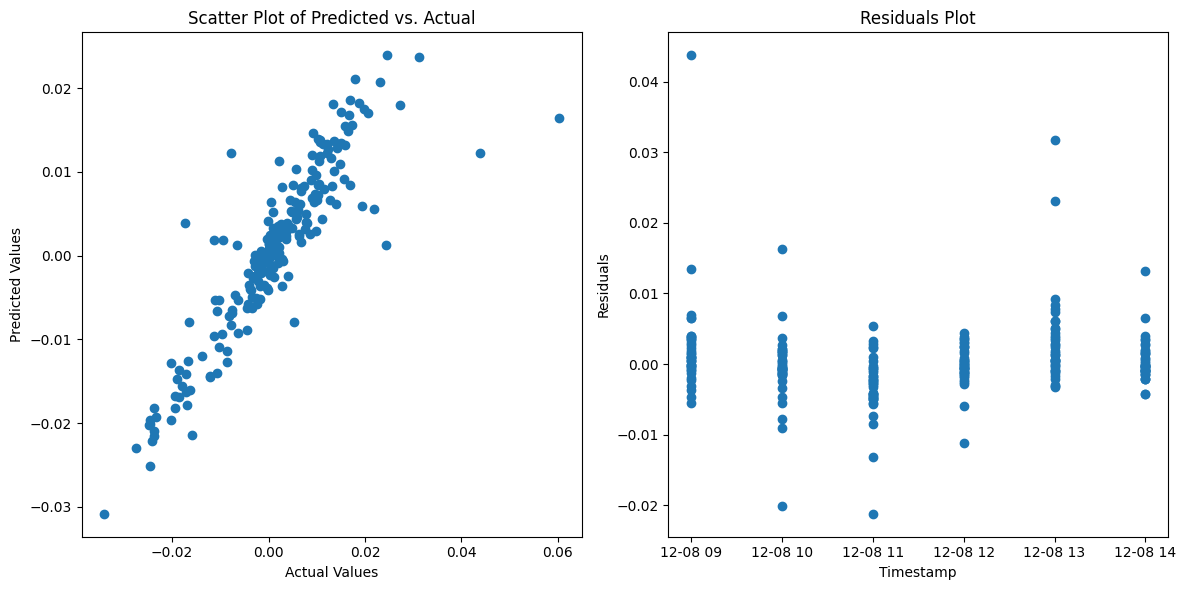

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt


def prepare_data(data, symbol, features, target='Hourly_Return'):
    symbol_data = data[data['Symbol'] == symbol].copy()
    symbol_data = symbol_data.sort_index()

    symbol_data = symbol_data.dropna(subset=[target])
    symbol_data = symbol_data.replace([np.inf, -np.inf], np.nan).dropna(subset=[target])

    threshold = 1e6
    symbol_data = symbol_data[abs(symbol_data[target]) < threshold]

    X = symbol_data[features]
    y = symbol_data[target]

    return X, y

def train_and_predict(X, y, X_predict):
    model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X, y)
    return model.predict(X_predict)

# Features to use
features = ['Hour', 'Day', 'Volume', 'Month', 'DayOfWeek', 'Open', 'High', 'Low', 'Close']

# Get the latest timestamp in the dataset
latest_timestamp = df.index.max()

# Get the last 5 hours of data
last_5_hours = df[(df.index >= latest_timestamp - pd.Timedelta(hours=5)) & (df.index <= latest_timestamp)]

# Check data availability for each symbol
for symbol in symbols:
    symbol_data = last_5_hours[last_5_hours['Symbol'] == symbol]
    print(f"Symbol: {symbol}, Last 5 hours data shape: {symbol_data.shape}")
    if not symbol_data.empty:
        print(symbol_data.head())

results = []

for symbol in symbols:
    X, y = prepare_data(df, symbol, features)

    # Debugging: Print shape of X and y
    print(f"Symbol: {symbol}, X shape: {X.shape}, y shape: {y.shape}")

    # Get the last 5 hours data for this symbol
    X_predict = last_5_hours[last_5_hours['Symbol'] == symbol][features]

    # Debugging: Print shape of X_predict
    print(f"Symbol: {symbol}, X_predict shape: {X_predict.shape}")

    if not X_predict.empty:
        predictions = train_and_predict(X, y, X_predict)
        actual_values = last_5_hours[last_5_hours['Symbol'] == symbol]['Hourly_Return']

        for pred, actual, timestamp in zip(predictions, actual_values, X_predict.index):
            results.append({
                'Symbol': symbol,
                'Timestamp': timestamp,
                'Predicted': pred,
                'Actual': actual
            })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Debugging: Print results_df to check contents
print("\nResults DataFrame:")
print(results_df.head())

# Sort the results by Symbol and Timestamp
results_df = results_df.sort_values(['Symbol', 'Timestamp'])

# Display the results
print(results_df.to_string(index=False))

# Calculate overall metrics
mse = mean_squared_error(results_df['Actual'], results_df['Predicted'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(results_df['Actual'], results_df['Predicted'])
r2 = r2_score(results_df['Actual'], results_df['Predicted'])

print("\nOverall Metrics:")
print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R2: {r2:.6f}")

# Calculate metrics for each symbol
symbol_metrics = results_df.groupby('Symbol').agg({
    'Predicted': ['mean', 'std'],
    'Actual': ['mean', 'std']
}).reset_index()

symbol_metrics.columns = ['Symbol', 'Predicted_Mean', 'Predicted_Std', 'Actual_Mean', 'Actual_Std']
print("\nMetrics by Symbol:")
print(symbol_metrics.to_string())

grouped = results_df.groupby('Symbol').apply(lambda x: {
    'MAE': mean_absolute_error(x['Actual'], x['Predicted']),
    'MSE': mean_squared_error(x['Actual'], x['Predicted']),
    'RMSE': np.sqrt(mean_squared_error(x['Actual'], x['Predicted'])),
    'MAPE': np.mean(np.abs((x['Actual'] - x['Predicted']) / x['Actual'])) * 100
})

print(grouped)


plt.figure(figsize=(12, 6))

# Scatter Plot
plt.subplot(1, 2, 1)
plt.scatter(results_df['Actual'], results_df['Predicted'])
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Scatter Plot of Predicted vs. Actual')

# Residual Plot
plt.subplot(1, 2, 2)
residuals = results_df['Actual'] - results_df['Predicted']
plt.scatter(results_df['Timestamp'], residuals)
plt.xlabel('Timestamp')
plt.ylabel('Residuals')
plt.title('Residuals Plot')

plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Load your DataFramedf = pd.read_csv('data.csv')

#df['Date'] = pd.to_datetime(df['Date'])
# Assuming your DataFrame doesn't have a 'Date' column, let's create one
df['Date'] = pd.date_range(start='2024-01-01', periods=len(df), freq='H')

# Create lag features
def create_lag_features(data, lag=1):
    df = data.copy()
    for i in range(1, lag + 1):
        df[f'lag_{i}'] = df['Hourly_Return'].shift(i)
    df.dropna(inplace=True)
    return df

# Prepare data for a specific symbol
def prepare_data(data, symbol, exog_features, lag=1):
    symbol_data = data[data['Symbol'] == symbol].dropna(subset=['Hourly_Return'])
    symbol_data = create_lag_features(symbol_data, lag)
    features = exog_features + [f'lag_{i}' for i in range(1, lag + 1)]
    X = symbol_data[features]
    y = symbol_data['Hourly_Return']
    # Return only X and y, not the split data
    return X, y

# Model functions
def random_forest_model(X_train, y_train, X_test):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return model, predictions # Return the model object

# Symbols list
symbols = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'ADAUSDT', 'DOGEUSDT', 'XRPUSDT', 'DOTUSDT',
           'UNIUSDT', 'LTCUSDT', 'LINKUSDT', 'BCHUSDT', 'SOLUSDT', 'MATICUSDT', 'AVAXUSDT',
           'XLMUSDT', 'VETUSDT', 'TRXUSDT', 'FILUSDT', 'ETCUSDT', 'ALGOUSDT', 'ATOMUSDT',
           'FTTUSDT', 'ICPUSDT', 'EGLDUSDT', 'AAVEUSDT', 'XTZUSDT', 'THETAUSDT', 'AXSUSDT',
           'MKRUSDT', 'SUSHIUSDT', 'RUNEUSDT', 'ZILUSDT', 'KSMUSDT', 'GRTUSDT', 'COMPUSDT',
           'ENJUSDT', 'MANAUSDT', 'BATUSDT', 'DASHUSDT']

# Select top features based on importance
top_features = ['Hour', 'Day', 'Volume', 'Month', 'DayOfWeek']

# DataFrame to store the predictions
results = []

# Prepare and predict for each symbol
for symbol in symbols:
    X, y = prepare_data(df, symbol, top_features, lag=3)
    # Split data into train and test sets here
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model, predictions = random_forest_model(X_train, y_train, X_test) # Get the model object

    # Get the latest timestamp for this symbol
    latest_timestamp = df[df['Symbol'] == symbol]['Date'].max()

    # Calculate the next hour
    next_hour = latest_timestamp + pd.Timedelta(hours=1)

    # Prepare data for prediction (CORRECTED BLOCK)
    last_data = df[df['Symbol'] == symbol].iloc[-3:][top_features]
    X_predict_next = pd.DataFrame(index=[next_hour], columns=top_features)
    X_predict_next['Hour'] = next_hour.hour
    X_predict_next['Day'] = next_hour.day
    X_predict_next['Month'] = next_hour.month
    X_predict_next['DayOfWeek'] = next_hour.dayofweek

    # Prepare data for prediction
    last_data = df[df['Symbol'] == symbol].iloc[-3:][top_features]
    X_predict_next = pd.DataFrame(index=[next_hour], columns=top_features)
    for feature in top_features:
        X_predict_next[feature] = last_data[feature].mean()  # Example:
# Add lag features
    for i in range(1, 4):
        X_predict_next[f'lag_{i}'] = y.iloc[-i]

    # Predict the next hour
    prediction_next = model.predict(X_predict_next) # Use the model object to predict

    # Combine actual and predicted values
    symbol_results = pd.DataFrame({
        'Symbol': symbol,
        'Predicted': prediction_next,
        'Date': [next_hour]
    })

    # Append to the results list
    results.append(symbol_results)

# Concatenate all results
all_results = pd.concat(results)

# Display the final results table
print(all_results)

<ipython-input-12-4dab239002b3>:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['Date'] = pd.date_range(start='2024-01-01', periods=len(df), freq='H')


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.